In [68]:
# Tratamiento de datos
# -----------------------------------------------------------------------
import pandas as pd
import numpy as np

# Configuración
# -----------------------------------------------------------------------
pd.set_option('display.max_columns', None) # para poder visualizar todas las columnas de los DataFrames

# Visualización
# ------------------------------------------------------------------------------
import matplotlib.pyplot as plt
import seaborn as sns

# Cálculos matemáticos
# ------------------------------------------------------------------------------
from math import pi

# Gestión de los warnings
# -----------------------------------------------------------------------
import warnings
warnings.filterwarnings("ignore")

In [3]:
# Lectura csv final
df_final = pd.read_csv('../files/hr_final.csv', index_col = 0)
df_final.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
EmployeeNumber,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,41,True,Travel Rarely,1102,Sales,1,2,Life Sciences,2,Female,94,3,2,Sales Executive,4,Single,5993.0,19479,8,True,11,3,1,0,8,0,1,6,4,0,5
2,49,False,Travel Frequently,279,Research & Development,8,1,Life Sciences,3,Male,61,2,2,Research Scientist,2,Married,5130.0,24907,1,False,23,4,4,1,10,3,3,10,7,1,7
4,37,True,Travel Rarely,1373,Research & Development,2,2,Other,4,Male,92,2,1,Laboratory Technician,3,Single,2090.0,2396,6,True,15,3,2,0,7,3,3,0,0,0,0
5,33,False,Travel Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,56,3,1,Research Scientist,3,Married,2909.0,23159,1,True,11,3,3,0,8,3,3,8,7,3,0
7,27,False,Travel Rarely,591,Research & Development,2,1,Medical,1,Male,40,3,1,Laboratory Technician,2,Married,3468.0,16632,9,False,12,3,4,1,6,3,3,2,2,2,2


### Recuperamos la división de variables utilizada en el 02_Analisis

In [4]:
variables_categoricas = ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole',  'MaritalStatus', 'OverTime']

In [5]:
variables_encuesta = ['EnvironmentSatisfaction', 'JobInvolvement','JobSatisfaction','RelationshipSatisfaction','WorkLifeBalance']

In [6]:
variables_salario = ['DailyRate','HourlyRate', 'MonthlyRate','MonthlyIncome','PercentSalaryHike']
variables_tiempo = [ 'TotalWorkingYears','YearsAtCompany','YearsInCurrentRole','YearsSinceLastPromotion','YearsWithCurrManager']
variables_numericas1 = ['DistanceFromHome','JobLevel','PerformanceRating','StockOptionLevel','TrainingTimesLastYear']
variables_numericas2= ['Age', 'Education','NumCompaniesWorked']

In [7]:
# Conversión de Attrition en numérica para los gráficos
df_final['AttritionNum'] = df_final['Attrition'].astype(int)

### Correlación de attrition (abandono de la empresa) con las variables categóricas

In [8]:
# Función para dibujar gráficos de barras agrupando por abandono de empresa 
def crear_graficos_barras(df, variables):
    
    for col in variables:

        # Barplot (tasa de attrition por categoría)
        plt.figure(figsize=(8, 5))
        tasa = df.groupby(col)['AttritionNum'].mean().sort_values(ascending=False)
        sns.barplot(x=tasa.index, y=tasa.values, palette='mako')
        plt.title(f'Tasa de Abandono por {col}')
        plt.ylabel('Proporción que se va')
        plt.xlabel(col)
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()

In [ ]:
# Función para dibujar gráficos de tarta agrupando por abandono de empresa 
def crear_pie(df, variables):
    
    for col in variables:

        plt.figure(figsize=(6, 6))
        conteo = df[col].value_counts()
        separacion = [0.03] * len(conteo)

        wedges, textos_categoria, textos_porcentaje = plt.pie(
            conteo.values,
            labels=conteo.index,
            autopct='%1.1f%%',
            colors=sns.color_palette('mako', len(conteo)),
            startangle=90,
            explode=separacion
        )

    # Las etiquetas de categoría en negro/color normal
    for texto in textos_categoria:
        texto.set_color('black')

    # Solo los porcentajes en blanco
    for texto in textos_porcentaje:
        texto.set_color('white')

    plt.title(f'Distribución de {col}')
    plt.tight_layout()
    plt.show()
 
 

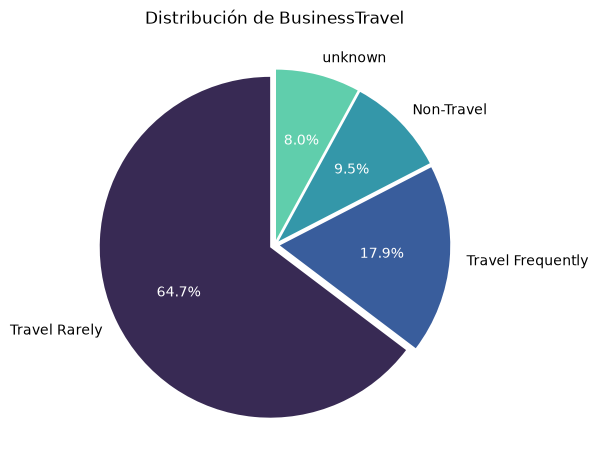

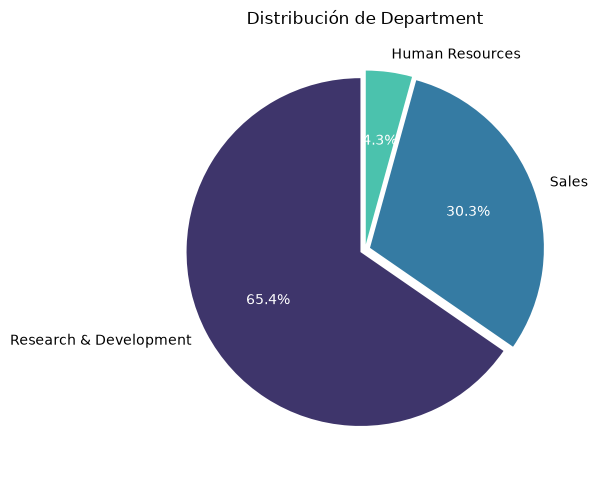

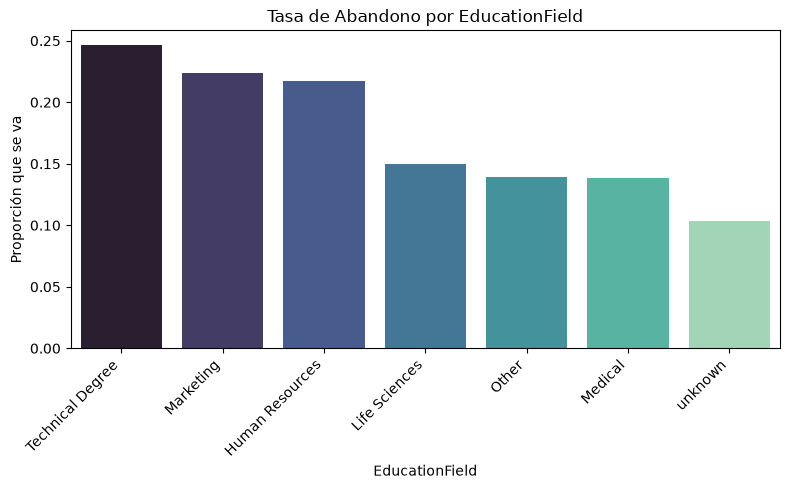

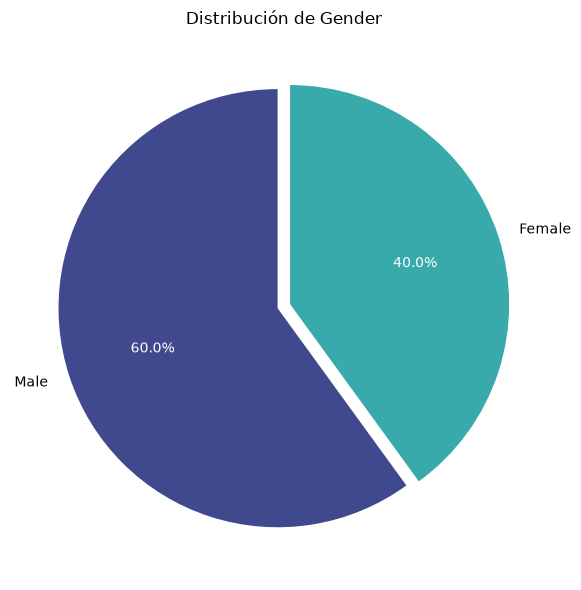

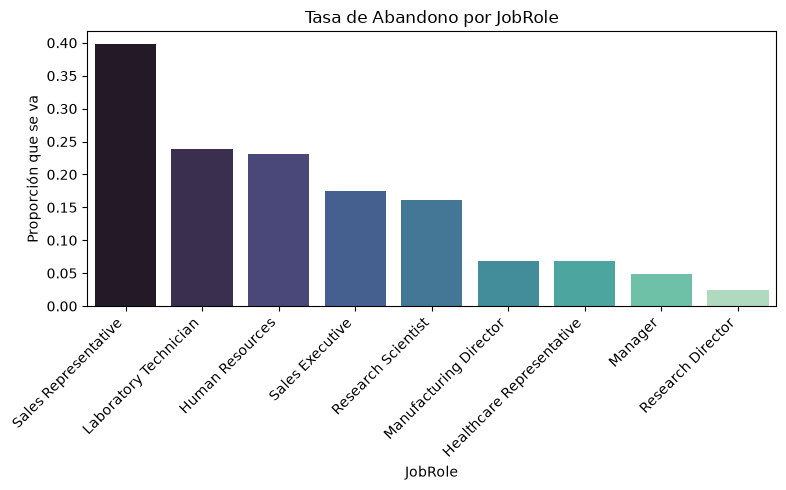

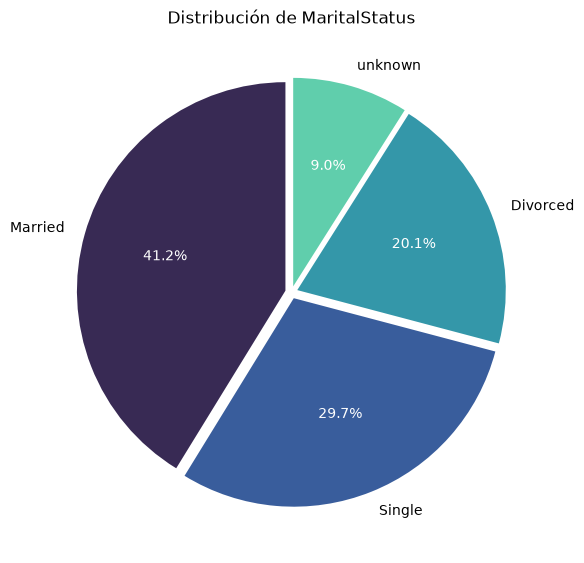

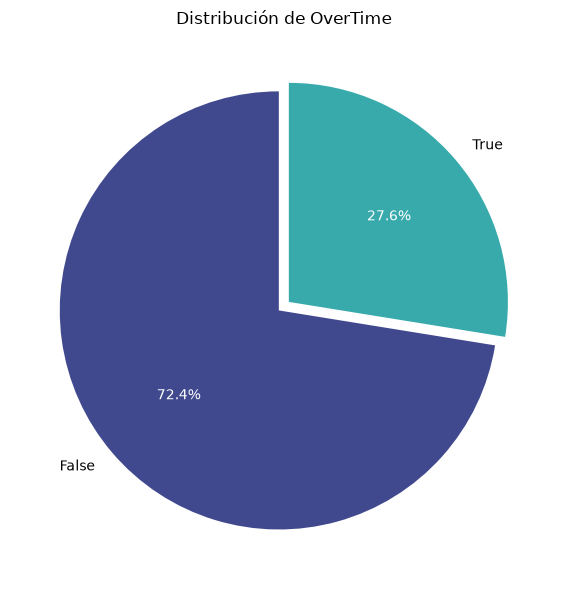

In [10]:
# Ejecución de las funciones para variables categóricas
for variable in variables_categoricas:
    if df_final[variable].nunique() > 5:
        crear_graficos_barras(df_final, [variable])
    else:
        crear_pie(df_final, [variable])

**Análisis de visualización de la correlación de Attrition (abandono de la empresa) con las variables categóricas:**
* *`BusinessTravel`, `Department`, `EducationField`, `Gender`, `JobRole`, `MaritalStatus`, `OverTime`*

- `BusinessTravel`: Se observa una mayor tasa de abandono de los empleados que viajan con frecuencia pero se trata de cifras muy escalonadas. Hay que señalar que hay una cantidad importante de unknown, por lo que no sabemos si esos trabajadores viajan o no.
- `Department`: Los de Sales son los que más se marchan, seguidos muy de cerca por los de Human Resources y ya algo más distanciados por los de Research and Development. Estos son los tres departamento principales.
- `EducationField`: Abandonan más los que tienen un Technical Degree, seguidos a poca distancia de Marketing y Human Resources (estos dos casi igual). Luego ya se produce un salto con el resto de titulaciones.
- `Gender`: Se van más los hombres que las mujeres, aunque la diferencia no es muy grande y además es que también hay más hombres que mujeres (60%-40% respectivamente).
- `JobRole`: El porcentaje de abandono de los Sale Representative es mucho mayor respecto de los siguientes, Laboratory Technician y Human Resources. Luego hay otro salto con Sales Executive y Research Scientist. Y otro salto con las siguientes categorías que ya están más igualadas.
- `MaritalStatus`: Los solteros se van mayoritariamente. A continuación, un gran desnivel y los demás, Married y Divorced que están igualados. Hay que decir que hay un gran número de unknown en porcentaje muy similar a Married.
- `OverTime`: Los que más horas extra hacen abandonan en un porcentaje muy elevado respecto a los que no las hacen.

### Correlación de attrition con las variables encuesta

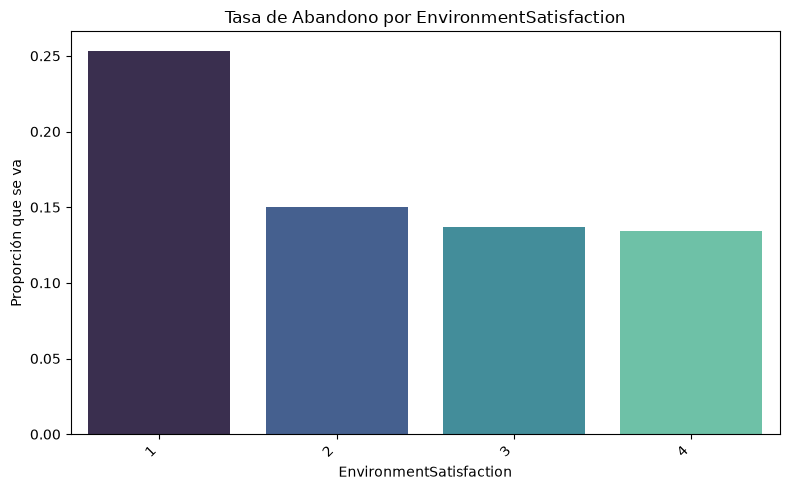

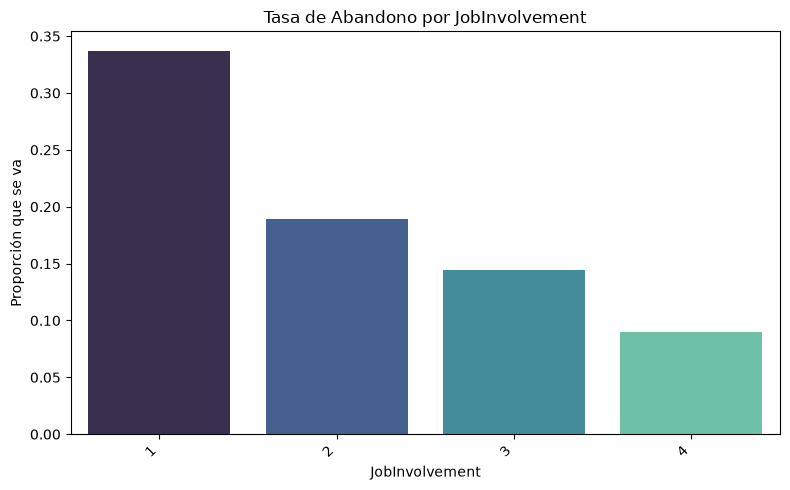

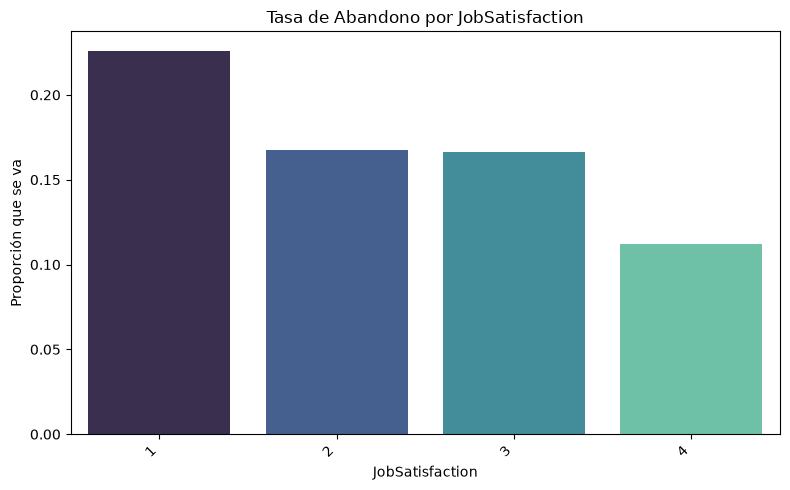

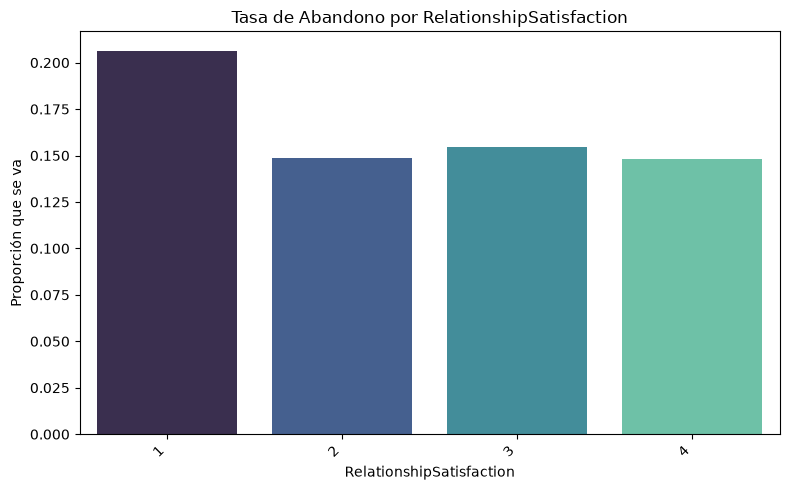

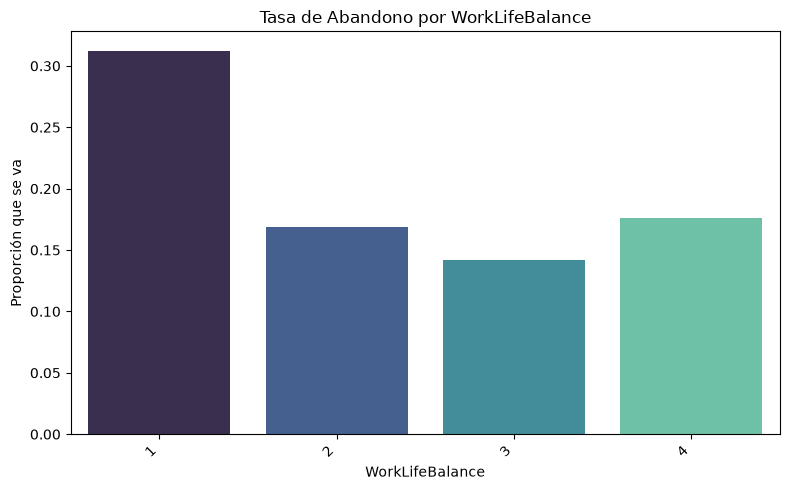

In [11]:
# Ejecución de la función para variables encuestas
crear_graficos_barras(df_final, variables_encuesta)

**Análisis de visualización de la correlación de Attrition (abandono de la empresa) con las variables encuesta:**
* *`EnvironmentSatisfaction`, `JobInvolvement`, `JobSatisfaction`, `RelationshipSatisfaction`, `WorkLifeBalance`*

- La tasa de abandono lógicamente es mucho más elevada en aquellos que no están satisfechos, siendo los más descontentos los que califican con una puntuación más baja a estas cuestiones: los que votan 1. Hay que destacar que siempre hay un salto entre el 1 y el resto: los que votan de 2 a 4. Este desnivel es mayor en `EnvironmentSatisfaction`, `JobInvolvement` y `WorkLifeBalance`

### Matriz de correlación entre variables numéricas

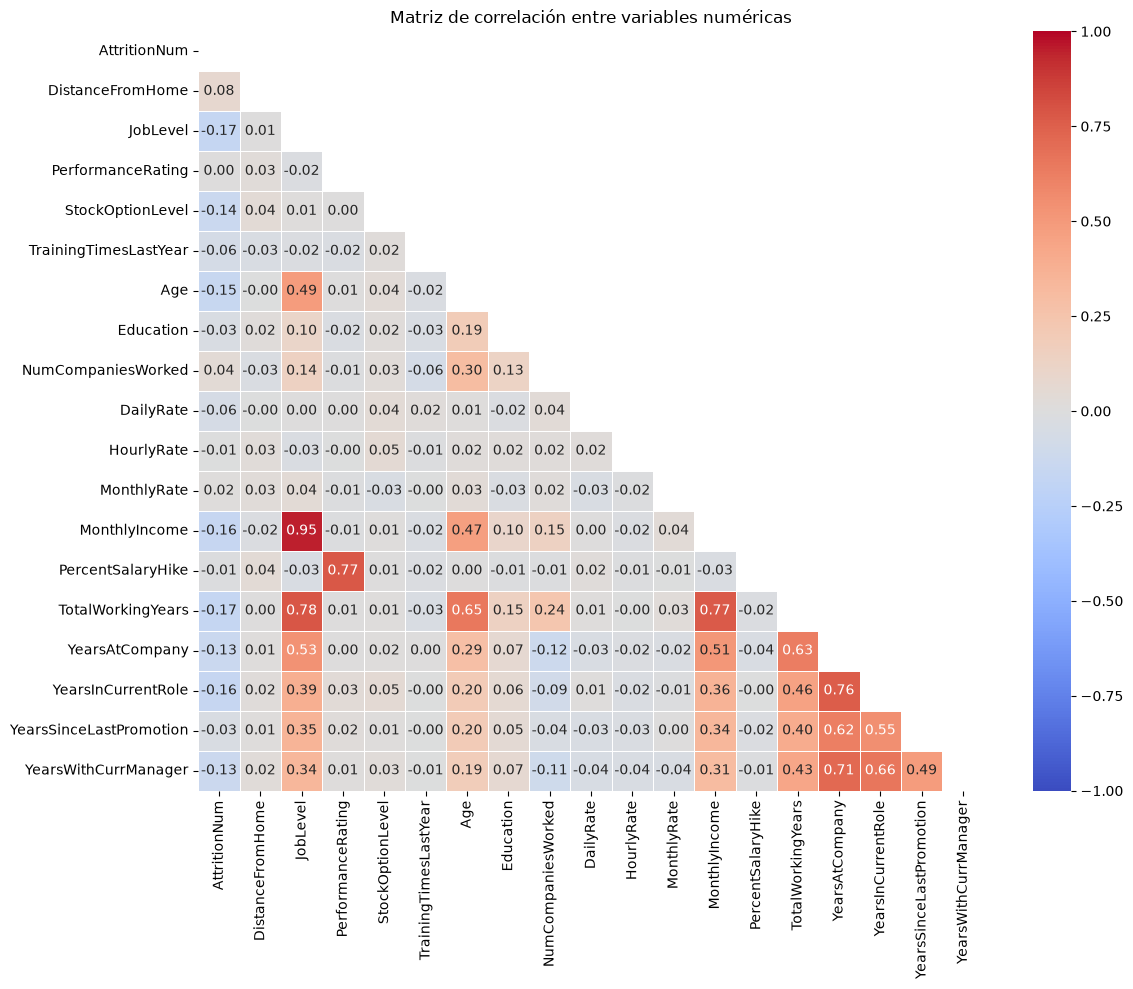

In [12]:
# Creación del mapa de correlación entre variables numericas y abandono
cols_heatmap = ['AttritionNum'] + list(dict.fromkeys(variables_numericas1 + variables_numericas2 + variables_salario + variables_tiempo)) 
correlacion_matrix = df_final[cols_heatmap].corr()

# Aplicación de máscara para evitar duplicidad en la matriz
masc = np.triu(np.ones_like(correlacion_matrix, dtype=bool)) 
plt.figure(figsize=(12, 10))
sns.heatmap(correlacion_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5, mask=masc, vmin=-1, vmax=1)
plt.title('Matriz de correlación entre variables numéricas')
plt.tight_layout()
plt.show()

Las correlaciones que más destacan son:

- `JobLevel` vs `MonthlyIncome`: 0.95 — El salario está determinado en gran parte por el nivel del puesto. 
- `JobLevel` vs `TotalWorkingYears`: 0.78 y `MonthlyIncome` vs `TotalWorkingYears`: 0.77 — Sigue la misma lógica que el anterior: más experiencia → más nivel → más salario. Es un triángulo de variables redundantes entre sí.
- `PercentSalaryHike` vs `PerformanceRating`: 0.77 — el incremento salarial está directamente ligado a la evaluación de desempeño (bastante lógico, probablemente hasta parte de una política de la empresa).
- `YearsInCurrentRole` vs `YearsAtCompany`: 0.76 y `YearsWithCurrManager` vs `YearsAtCompany`: 0.71 — las variables de "tiempo" están todas muy correlacionadas entre sí: si llevas mucho tiempo en la empresa, es probable que lleves tiempo en el rol actual y con el mismo manager. Pero por otro  lado, nos indica un cierto estancamiento y falta de promoción del personal.
- `YearsInCurrentRole` vs `YearsWithCurrManager`: 0.66 y `YearsSinceLastPromotion` vs `YearsAtCompany`: 0.62 — mismo patrón.
- `Age` vs `TotalWorkingYears`: 0.65 — A mayor edad, más años trabajados en total.
- `Age` vs `JobLevel`: 0.49 y `Age` vs `MonthlyIncome`: 0.47 — la edad se asocia moderadamente con progresión de carrera y salario.

Las correlaciones de `Attrition` más relevantes (aunque débiles) son:

- `JobLevel`: -0.17 — a mayor nivel de puesto, ligeramente menos attrition.
- `TotalWorkingYears`: -0.17 — más experiencia total, algo menos de fuga.
- `MonthlyIncome`: -0.16 — salario más alto, algo menos de attrition (esperado, aunque el efecto es más débil de lo que muchos asumen).
- `YearsInCurrentRole`: -0.16 y Age: -0.15 — en la misma línea: más estabilidad/madurez, menos abandono.
- `StockOptionLevel`: -0.14 — algo de efecto retentivo.

En resumen: Todas negativas y débiles: ninguna variable numérica por sí sola "explica" el attrition.  
Como se ve, hasta este punto, es `Overtime`, y `JobRole`, lo que más pesa a la hora de abandonar la empresa.

### Matriz de correlación entre attrition y variables de encuesta

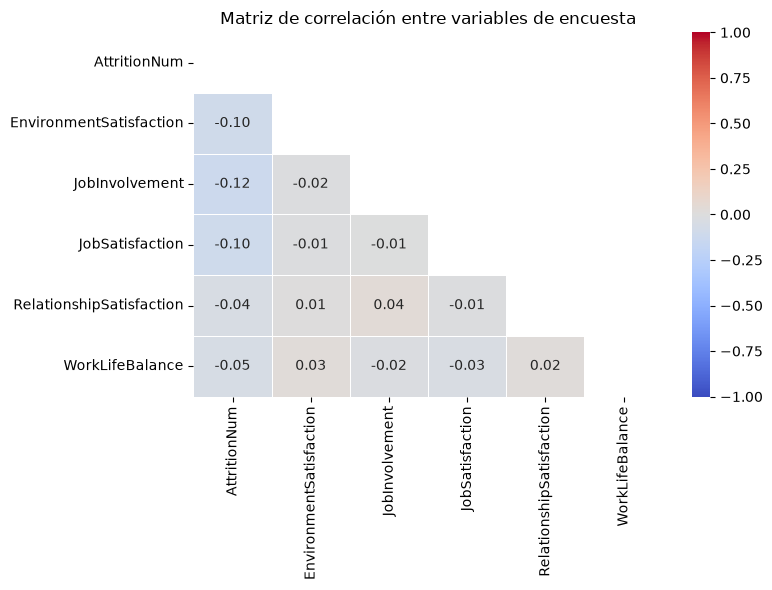

In [13]:
# Creación del mapa de correlación entre variables de encuenta y abandono
cols_heatmap2 = ['AttritionNum'] + variables_encuesta

# Se usa el metodo de 'spearman' porque mide relaciones monótonas
correlacion_matrix2 = df_final[cols_heatmap2].corr(method='spearman')

# Aplicación de máscara para evitar duplicidad en la matriz
masc2 = np.triu(np.ones_like(correlacion_matrix2, dtype=bool)) 
plt.figure(figsize=(8, 6))
sns.heatmap(correlacion_matrix2, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5, mask=masc2, vmin=-1, vmax=1)
plt.title('Matriz de correlación entre variables de encuesta')
plt.tight_layout()
plt.show()

Esta matriz es aún más "plana" que la anterior: aquí ni siquiera hay correlaciones fuertes entre las propias variables de encuesta, cada una de ellas está midiento algo distinto e independiente de las demás.  
Con `Attrition`: todas negativas por lo que a más satisfacción, menos fuga, pero ninguna pasa de -0.12. Es decir, ninguna de estas variables de encuesta, tomada de forma individual y lineal, predice bien el attrition.

### Correlación de attrition con las variables numéricas1

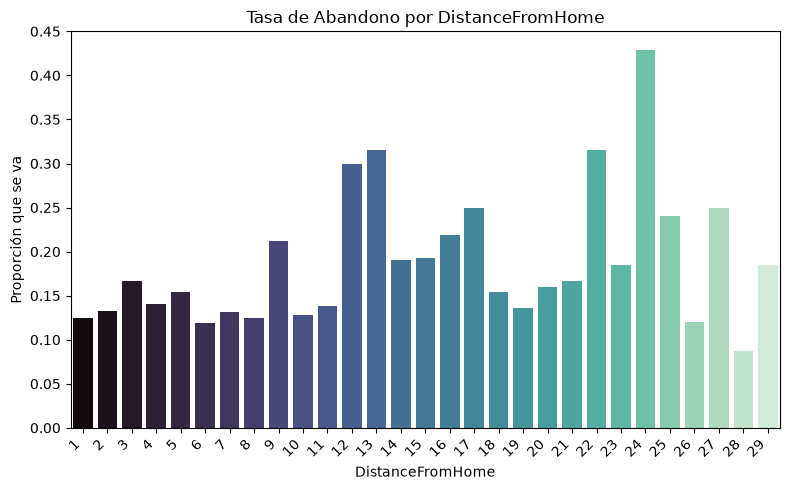

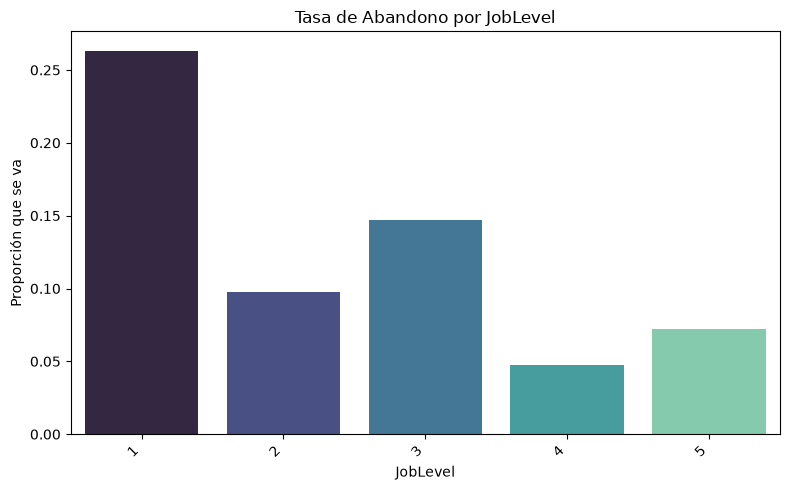

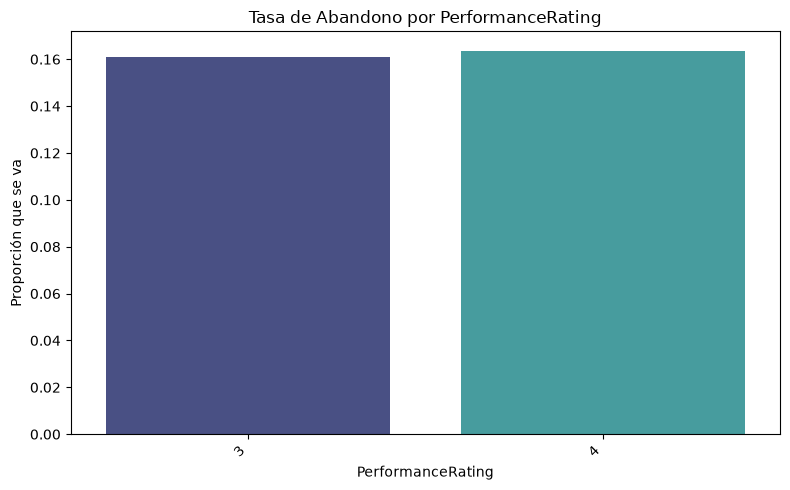

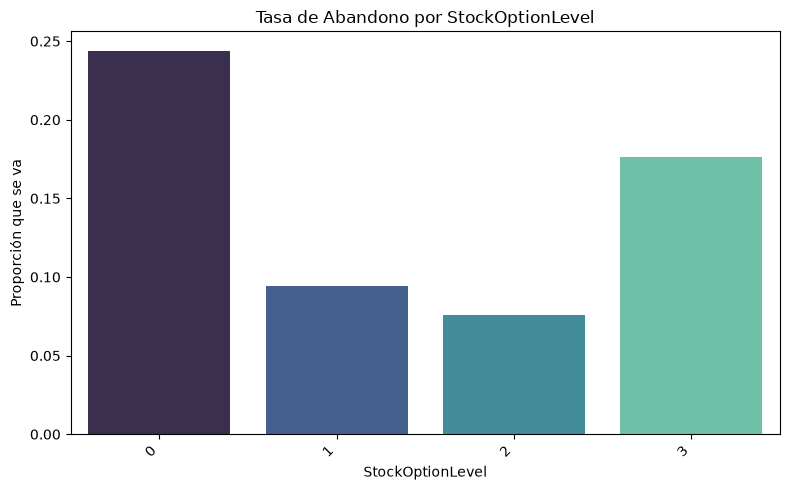

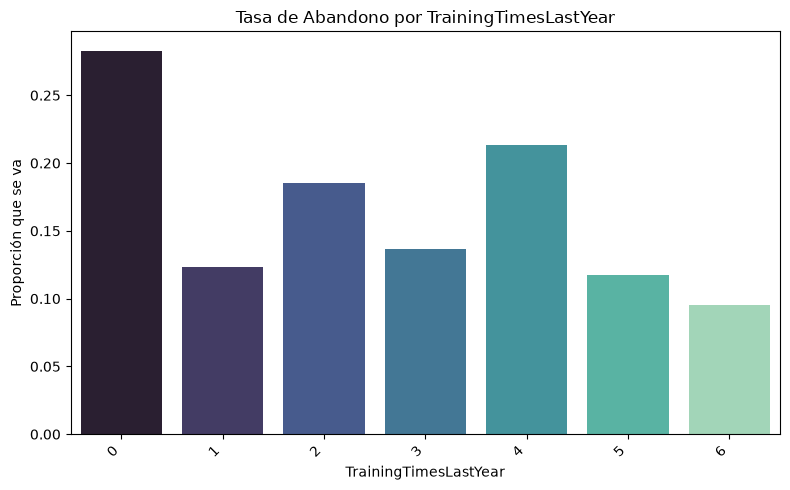

In [14]:
# Ejecución de la función para variables numéricas 1
crear_graficos_barras(df_final, variables_numericas1)

Estas 5 gráficas muestran la tasa de abandono del primer grupo de variables (variables_numericas1). Aunque son variables "numéricas", varias se comportan más como categóricas discretas, así que este tipo de gráfico de barras encaja mejor que un boxplot.
- `DistanceFromHome`: Hay una tendencia general: a mayor distancia, la tasa de abandono tiende a subir. 
- `JobLevel`: Los empleados de nivel más bajo son los que más se van, algo típico en casi cualquier empresa (menor compromiso, más ofertas alternativas, menor "costo de oportunidad" de irse).
- `PerformanceRating`: Prácticamente sin diferencia. Esto confirma la correlación casi nula que ya habíamos visto (0.00). Un detalle importante: este dataset solo tiene dos valores posibles de PerformanceRating, 3 y 4. No hay ratings bajos, lo cual limita mucho la variabilidad y explica por qué esta variable aporta tan poco.
- `StockOptionLevel`: Patrón muy claro y con sentido de negocio:  
Nivel 0 (sin stock options): ~24% de abandono, el más alto
Niveles 1 y 2: caen fuertemente a ~9% y ~7%
Nivel 3: sube de nuevo a ~17%  
La lectura principal: no tener stock options está asociado a mucho más abandono consistente con la idea de que los incentivos a largo plazo retienen empleados. El repunte en nivel 3 es un poco contraintuitivo; podría deberse a un grupo pequeño de empleados con perfiles distintos, por ejemplo, trabajadores senior que se van por otras razones.
- `TrainingTimesLastYear`: Patrón irregular, sin una tendencia lineal clara: el valor más alto de abandono está en 0 formaciones. Lo único razonablemente consistente es que 0 entrenamientos tiene la tasa más alta, sugiriendo que la falta total de formación se asocia a más fuga, pero el resto del patrón es demasiado ruidoso para sacar una conclusión sólida.

En conjunto:  
De las 5, las que muestran una señal más clara y útil son `JobLevel` y `StockOptionLevel` ambas con patrones consistentes y con sentido lógico de negocio. `DistanceFromHome` tiene una tendencia débil pero visible. `PerformanceRating` prácticamente no aporta nada (poca varianza en los datos). `TrainingTimesLastYear` es la más ambigua de este grupo.

### Correlación de attrition con las variables tiempo

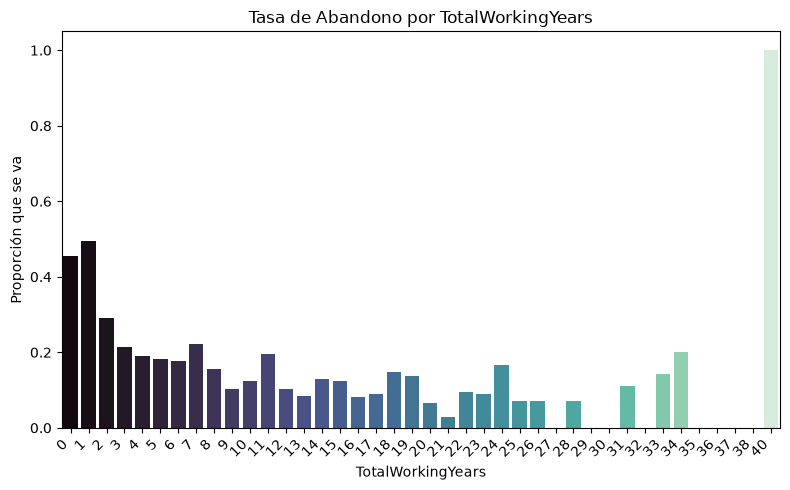

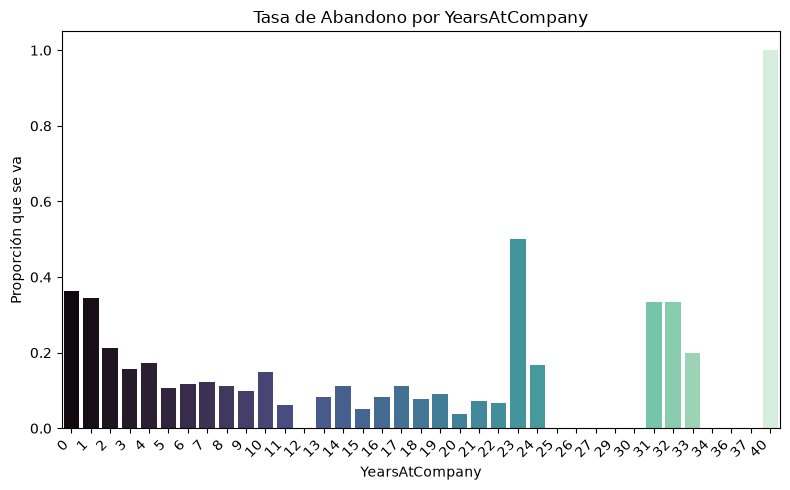

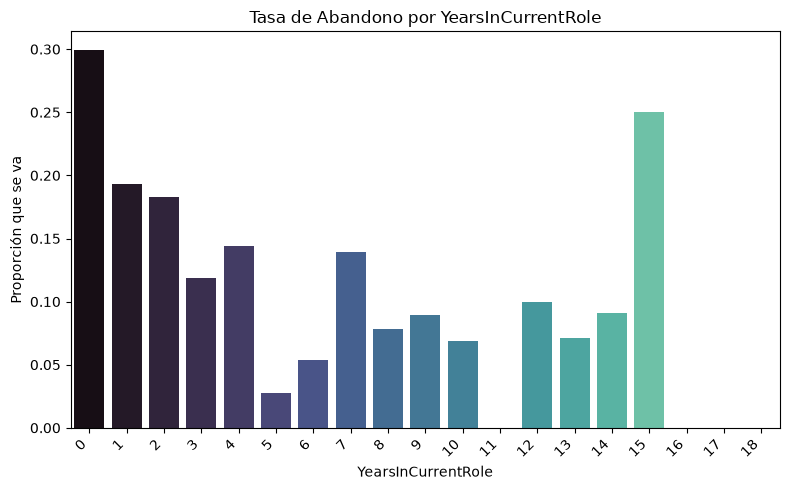

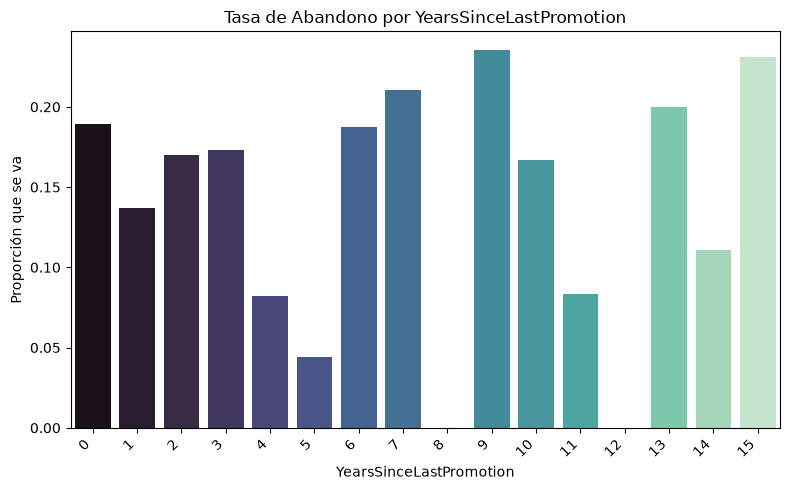

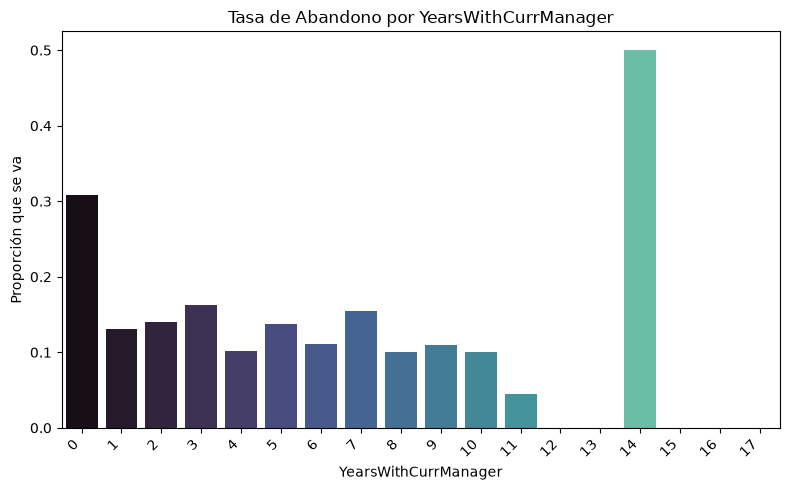

In [15]:
# Ejecución de la función para variables tiempo
crear_graficos_barras(df_final, variables_tiempo)

Este grupo (variables_tiempo) muestra el patrón más claro y consistente de todo el análisis: en las cinco variables, el abandono es alto al principio y baja según pasa el tiempo, con algunos picos extraños al final que hay que interpretar con cuidado.
- `TotalWorkingYears`: empleados con poca experiencia laboral son el grupo de mayor riesgo, con diferencia.
- `YearsAtCompany`: Mismo patrón que el anterior. Confirma lo que ya sabíamos por la matriz de correlación (-0.13): el riesgo de fuga es máximo en el primer año o dos, y luego la gente tiende a quedarse.
- `YearsInCurrentRole`: quienes acaban de empezar en un rol nuevo (recién ascendidos o recién contratados) tienen más riesgo de irse, quizás porque aún no se han adaptado o el puesto no cumplió expectativas.
- `YearsSinceLastPromotion`: éste es el más "ruidoso" e interesante, porque no sigue el mismo patrón descendente de los otros cuatro. No hay una tendencia de "a más tiempo, menos abandono". Llevar muchos años sin un ascenso puede generar frustración y motivar la salida, contrarrestando el efecto de "antigüedad = estabilidad" que vemos en las otras variables.
- `YearsWithCurrManager`: Similar a `YearsInCurrentRole`.Cambio reciente, de manager, en este caso se asocia a más riesgo de fuga.  
Conclusión del grupo:  
El principal mensaje es que el riesgo de abandono es mucho más alto en los primeros 2 años de cualquier situación (en la empresa, en el rol, siendo manager, en la carrera en general), y luego se estabiliza.   
La excepción interesante es `YearsSinceLastPromotion`, que rompe el patrón: ahí el riesgo se da cuando pasa mucho tiempo sin ascenso, sugiriendo una causa distinta de abandono: estancamiento de carrera, no falta de adaptación.

### ¿Por qué se van los que llevan más años trabajando (en la compañía y en total)?

In [16]:
#Para comprobar si el alto porcentaje de los que llevan más años trabajando en la compañía y en total y se va es debido a la jubilación


# Personas que llevan más de 35 años en la compañía
mas_35_compania = df_final[df_final["YearsAtCompany"] > 35]

mas_35_compania[["Age", "YearsAtCompany", "TotalWorkingYears", "AttritionNum"]]

,Age,YearsAtCompany,TotalWorkingYears,AttritionNum
EmployeeNumber,,,,
131,58,37,38,0
165,58,40,40,1
374,55,36,37,0
1578,55,36,36,0


In [17]:
# Personas que llevan más de 35 años trabajando en total
mas_35_total = df_final[df_final["TotalWorkingYears"] > 35]

mas_35_total[["Age", "YearsAtCompany", "TotalWorkingYears", "AttritionNum"]]

,Age,YearsAtCompany,TotalWorkingYears,AttritionNum
EmployeeNumber,,,,
112,56,6,37,0
131,58,37,38,0
165,58,40,40,1
254,55,24,36,0
374,55,36,37,0
532,56,7,36,0
597,55,10,37,0
825,58,31,40,1
1250,54,10,36,0


Desconocemos la edad de jubilación del país al que pertenece la empresa. Pero tras ver los gráficos correspondientes a `TotalWorkingYears` y `YearsAtCompany`, se podía pensar que el pico de salidas de aquellos que más años llevan trabajando y que más años llevan en la compañía se debe a la jubilación. 

Tras analizar los resultados de la tabla, el pico en el gráfico se debe a que las dos personas de 58 años de edad, que tras haber trabajado 40 años (una de ellas ha hecho toda su vida laboral en la compañía) se han marchado (es decir, el 100% de los que han trabajado 40 años). Lo mismo ocurre con `YearsAtCompany`, la única persona que lleva 40 años en la empresa se ha ido, por tanto corresponde al 100%.

* CONCLUSIÓN: No se puede afirmar con rotundidad que se debe a la jubilación ya que desconocemos la edad reglamentaria de retiro en el país en el que opera la empresa, pero apunta a que esas dos personas se han jubilado o prejubilado tras 40 años trabajados, por lo que su caso no sería reseñable para este estudio. 

### Agrupación en rangos salariales para el estudio de MonthlyIncome

In [18]:
# Análisis MonthlyIncome
print (f'Mínimo: {df_final["MonthlyIncome"].min()}')
print (f'Máximo: {df_final["MonthlyIncome"].max()}')

Mínimo: 1009.0
Máximo: 19999.0


In [19]:
# División en 8 intervalos del mismo tamaño
df_final["RangoSalarial"] = pd.cut(
    df_final["MonthlyIncome"],
    bins=8)

In [20]:
# Visualización de los intervalos
df_final["RangoSalarial"].value_counts().sort_index()

RangoSalarial
(990.01, 3382.75]      444
(3382.75, 5756.5]      448
(5756.5, 8130.25]      207
(8130.25, 10504.0]     125
(10504.0, 12877.75]     60
(12877.75, 15251.5]     55
(15251.5, 17625.25]     54
(17625.25, 19999.0]     77
Name: count, dtype: int64

In [21]:
# Se calcula el porcentaje de empleados que se han quedado en la empresa por rango salarial
retencion_salario = df_final.groupby("RangoSalarial")["Attrition"].apply(lambda x: 1 - x.mean()) * 100

retencion_salario = retencion_salario.round(2)
retencion_salario.sort_index()

RangoSalarial
(990.01, 3382.75]       73.20
(3382.75, 5756.5]       87.28
(5756.5, 8130.25]       88.89
(8130.25, 10504.0]      81.60
(10504.0, 12877.75]     91.67
(12877.75, 15251.5]     90.91
(15251.5, 17625.25]    100.00
(17625.25, 19999.0]     93.51
Name: Attrition, dtype: float64

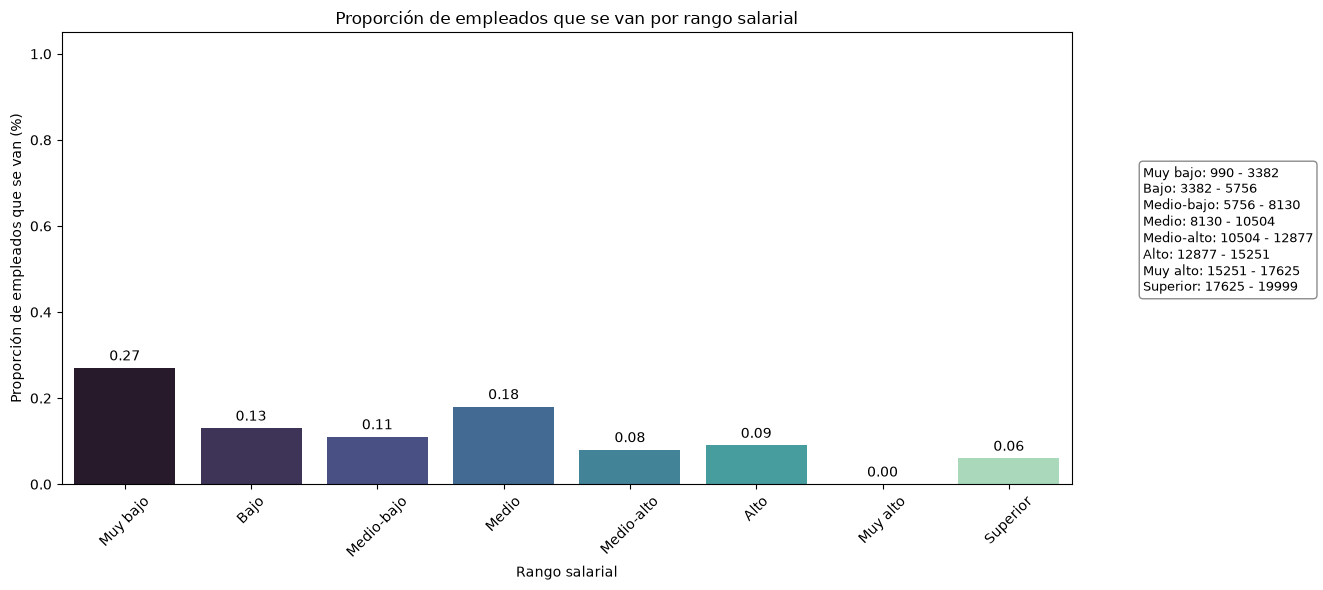

In [ ]:
# Etiquetas para los intervalos
labels_salario = [
    "Muy bajo",
    "Bajo",
    "Medio-bajo",
    "Medio",
    "Medio-alto",
    "Alto",
    "Muy alto",
    "Superior"
]

# Se crea la columna de rango salarial
df_final["RangoSalarial"] = pd.cut(
    df_final["MonthlyIncome"],
    bins=8,
    labels=labels_salario
)

proporcion_salida_salario = (
    df_final
    .groupby("RangoSalarial", observed=True)["AttritionNum"]
    .mean()
    .round(2)
)

intervalos_salario = pd.cut(
    df_final["MonthlyIncome"],
    bins=8
).cat.categories

# Gráfico
texto_leyenda = "\n".join(
    [
        f"{categoria}: {int(intervalo.left)} - {int(intervalo.right)}"
        for categoria, intervalo in zip(labels_salario, intervalos_salario)
    ]
)

plt.figure(figsize=(14, 6))

ax = sns.barplot(
    x=proporcion_salida_salario.index,
    y=proporcion_salida_salario.values,
    order=labels_salario,
    palette='mako'
)

plt.title("Proporción de empleados que se van por rango salarial")
plt.xlabel("Rango salarial")
plt.ylabel("Proporción de empleados que se van (%)")
plt.xticks(rotation=45)
plt.ylim(0, 1.05)

for i, valor in enumerate(proporcion_salida_salario.values):
    ax.text(
        i,
        valor + 0.01,
        f"{valor:.2f}",
        ha="center",
        va="bottom"
    )

plt.gcf().text(
    0.82,
    0.5,
    texto_leyenda,
    fontsize=9,
    ha="left",
    va="bottom",
    bbox=dict(
        boxstyle="round",
        facecolor="white",
        edgecolor="gray",
        alpha=0.9
    )
)

plt.tight_layout(rect=[0, 0, 0.78, 1])
plt.show()

In [ ]:
# Etiqueta más legible
df_final["Attrition_label"] = df_final["Attrition"].map({
    True: "Se marcha",
    False: "Se queda"
})

colores_mako = sns.color_palette("mako", 2)

# Función para comparar los que se van y los que se quedan con diferentes variables
def grafico_barras_attrition(variable, bins=None, orden=None):
    data = df_final.copy()

    if bins:
        data[variable + "_grupo"] = pd.cut(data[variable], bins=bins)
        variable_plot = variable + "_grupo"
    else:
        variable_plot = variable

    tabla = pd.crosstab(
        data[variable_plot],
        data["Attrition_label"],
        normalize="index"
    ) * 100

    if orden:
        tabla = tabla.reindex(orden)

    ax = tabla.plot(
        kind="bar",
        figsize=(10, 6),
        color=colores_mako,
        width=0.8
    )

    for container in ax.containers:
        ax.bar_label(
            container,
            fmt="%.1f%%",
            fontsize=9,
            padding=3
        )
    plt.title(f"Distribución de {variable} según Attrition")
    plt.xlabel(variable)
    plt.ylabel("% dentro de cada grupo Attrition")
    plt.xticks(rotation=45, ha="right")
    plt.legend(title="Attrition")
    plt.tight_layout()
    plt.show()


    # En este caso usamos normalize="index" para calcular el porcentaje de empleados 
    # que se marchan o se quedan dentro de cada categoría o intervalo de la variable analizada. 
    # Es decir, responde a la pregunta: de todos los empleados que tienen este valor concreto 
    # en la variable, ¿qué porcentaje se marcha y qué porcentaje permanece?

## Comparaciones entre los que se marchan y los que se quedan

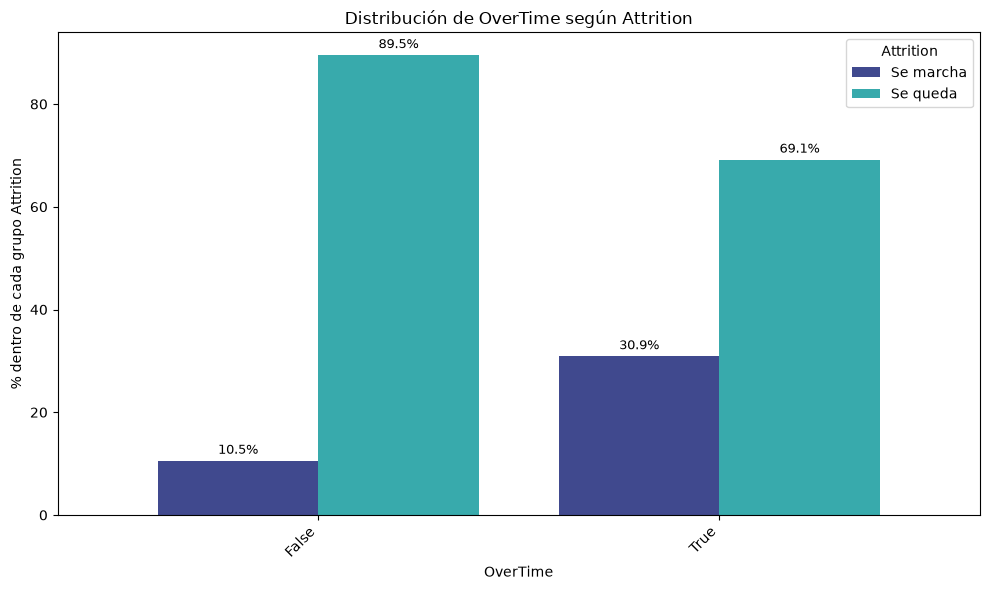

In [24]:
grafico_barras_attrition('OverTime', bins=None, orden=None)

En este gráfico, podemos observar que de los que no hacen horas extra, se marchan el 10.5% frente al 89,5% que se queda. Mientras, entre los que hacen horas extra, se va el 30,9%, frente al 69,1% que se queda.

Por tanto, se puede deducir que las horas extra pueden ser un factor que influya en la decisión de marcharse, pero no el único, ya que hay casi un 70% de empleados que, pese a hacer horas extra, se quedan.

In [25]:
#Análisis para ver si los que se van por horas extra puntúan mal el equilibrio vida-trabajo

# Filtramos empleados que hacen horas extra y se marchan
overtime_se_marcha = df_final[
    (df_final["OverTime"] == True) &
    (df_final["Attrition"] == True)
]

# Distribución de WorkLifeBalance dentro de ese grupo
distribucion_wlb_overtime_attrition = (
    overtime_se_marcha["WorkLifeBalance"]
    .value_counts(normalize=True)
    .sort_index() * 100
)

distribucion_wlb_overtime_attrition

WorkLifeBalance
1     8.0
2    25.6
3    56.8
4     9.6
Name: proportion, dtype: float64

In [ ]:
# Dentro de quienes hacen horas extra, ¿los que se marchan tienen peor WorkLifeBalance que los que se quedan?

comparacion_overtime_wlb = df_final[df_final["OverTime"] == True].groupby("Attrition_label")["WorkLifeBalance"].apply(
    lambda x: (x.isin([1, 2]).mean() * 100)
).reset_index(name="% WorkLifeBalance bajo")

comparacion_overtime_wlb

,Attrition_label,% WorkLifeBalance bajo
0,Se marcha,33.600000
1,Se queda,29.285714


Las horas extra parecen estar asociadas a mayor rotación, pero no necesariamente porque quienes las realizan valoren mucho peor su equilibrio vida-trabajo. La diferencia en `WorkLifeBalance` bajo entre quienes se marchan y quienes se quedan es limitada.

In [27]:
# Análisis para ver si quienes hacen horas extra y se marchan
# pertenecen a puestos de nivel más bajo o más alto

comparacion_overtime_level = (
    df_final[df_final["OverTime"] == True]
    .groupby("Attrition_label")["JobLevel"]
    .value_counts(normalize=True)
    .mul(100)
    .rename("porcentaje")
    .reset_index()
)

comparacion_overtime_level.round(2)

,Attrition_label,JobLevel,porcentaje
0,Se marcha,1,64.80
1,Se marcha,2,20.00
2,Se marcha,3,10.40
3,Se marcha,5,2.40
4,Se marcha,4,2.40
5,Se queda,2,42.50
6,Se queda,1,24.64
7,Se queda,3,16.79
8,Se queda,4,10.71
9,Se queda,5,5.36


In [28]:
#Qué nivel hace más horas extra

tabla_overtime_level = pd.crosstab(
    df_final["JobLevel"],
    df_final["OverTime"],
    normalize="index"
) * 100

tabla_overtime_level.round(1)

OverTime,False,True
JobLevel,,
1,72.4,27.6
2,73.0,27.0
3,72.5,27.5
4,68.9,31.1
5,73.9,26.1


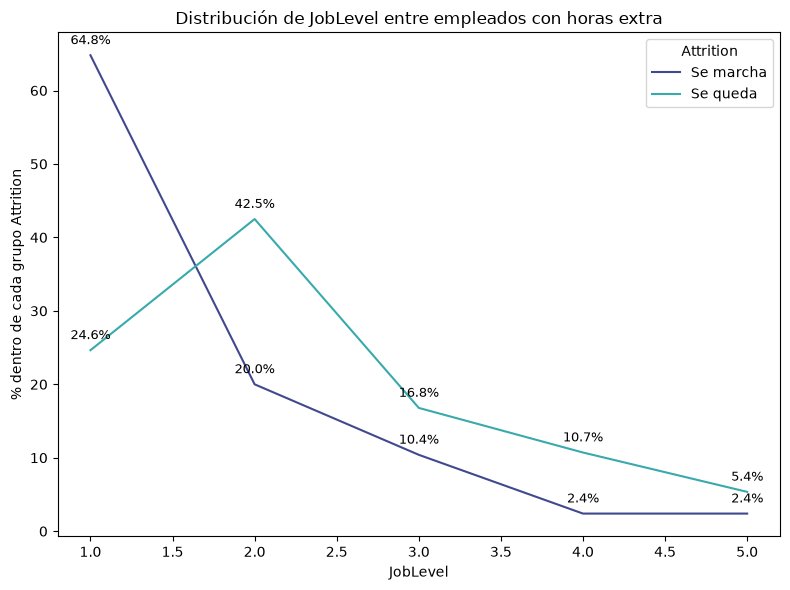

In [29]:
plt.figure(figsize=(8, 6))

ax = sns.lineplot(
    data=comparacion_overtime_level,
    x="JobLevel",
    y="porcentaje",
    hue="Attrition_label",
    palette=colores_mako
)

plt.title("Distribución de JobLevel entre empleados con horas extra")
plt.xlabel("JobLevel")
plt.ylabel("% dentro de cada grupo Attrition")
plt.legend(title="Attrition")

for _, fila in comparacion_overtime_level.iterrows():
    ax.annotate(
        f"{fila['porcentaje']:.1f}%",
        xy=(fila["JobLevel"], fila["porcentaje"]),
        xytext=(0, 8),
        textcoords="offset points",
        ha="center",
        fontsize=9
    )

plt.tight_layout()
plt.show()

Las horas extra no se concentran claramente en los niveles más bajos, ya que todos los JobLevel presentan porcentajes similares de empleados con `OverTime`=True. No obstante, cuando se combinan horas extra y bajo nivel profesional, la rotación aumenta de forma más notable.

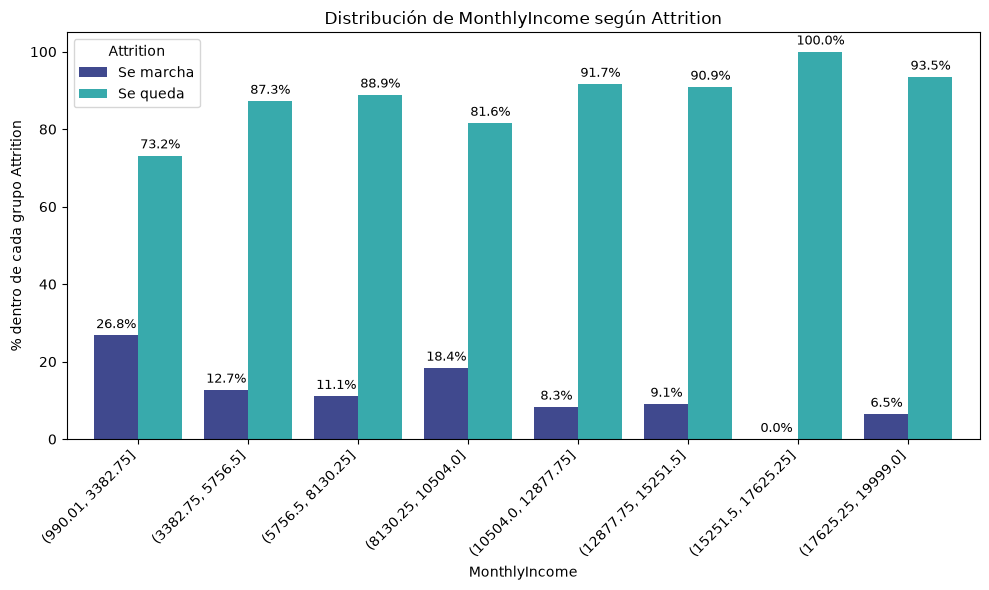

In [30]:
grafico_barras_attrition('MonthlyIncome', bins=8, orden=None)

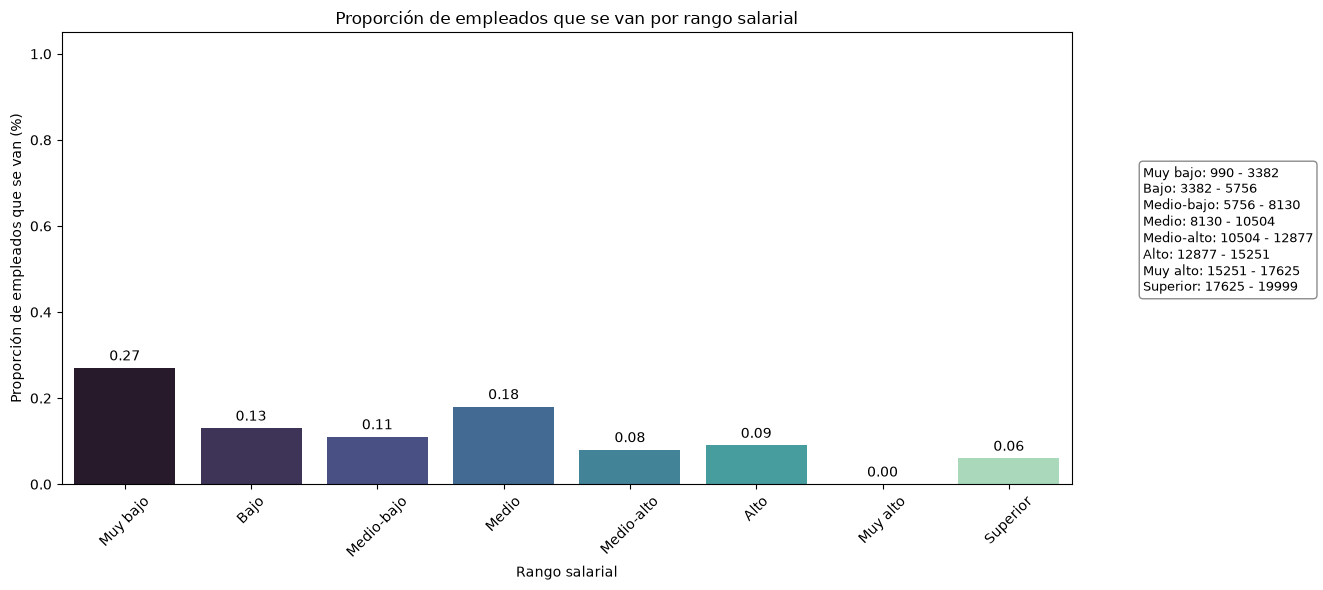

De acuerdo con el gráfico anteriormente hecho (recuperado para este análisis) sobre la proporción de empleados que se van por rango salarial, podemos confirmar que, efectivamente, el porcentaje de trabajadores que se marchan es mayor entre quienes los salarios más bajos. Salvando la excepción de los que tienen un salario medio (de 8130 a 10504), entre quienes también es mayor el porcentaje de los que se van en relación con el resto de grupos salariales, en el resto de intervalos el porcentaje de rotación se mantiene más o menos similar.

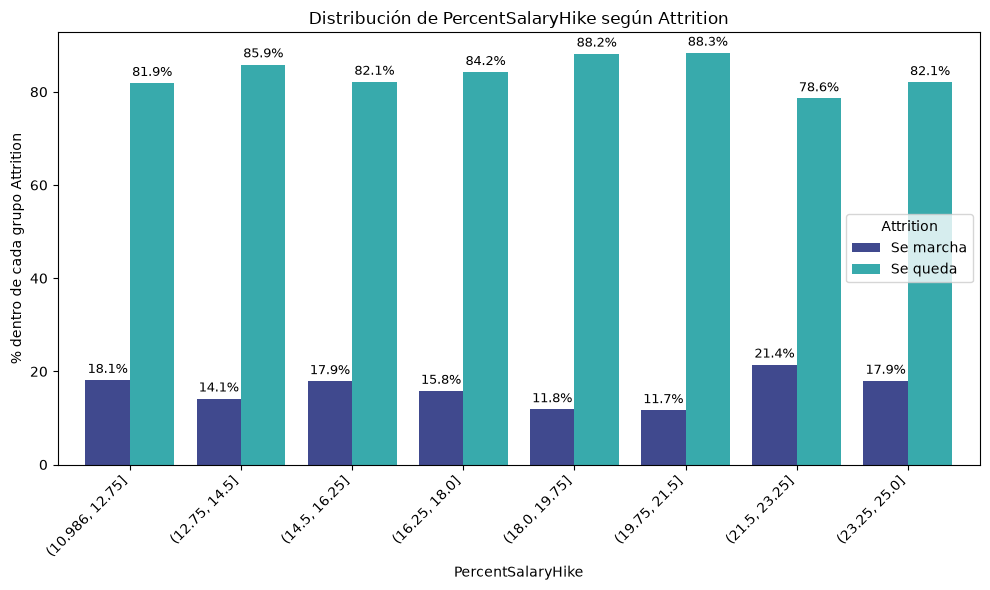

In [31]:
grafico_barras_attrition('PercentSalaryHike', bins=8, orden=None)

El porcentaje de incremento salarial no muestra una relación clara con la rotación. Aunque existen diferencias entre intervalos, no se observa una tendencia progresiva que indique que menores subidas salariales estén asociadas sistemáticamente a una mayor salida de empleados. De hecho, algunos tramos con incrementos más altos también presentan porcentajes de rotación elevados. Por tanto, `PercentSalaryHike` no parece actuar como una variable especialmente determinante por sí sola.

Para interpretar correctamente los tramos extremos, convendría revisar cuántos empleados hay en cada intervalo, ya que algunos porcentajes pueden estar condicionados por grupos pequeños.

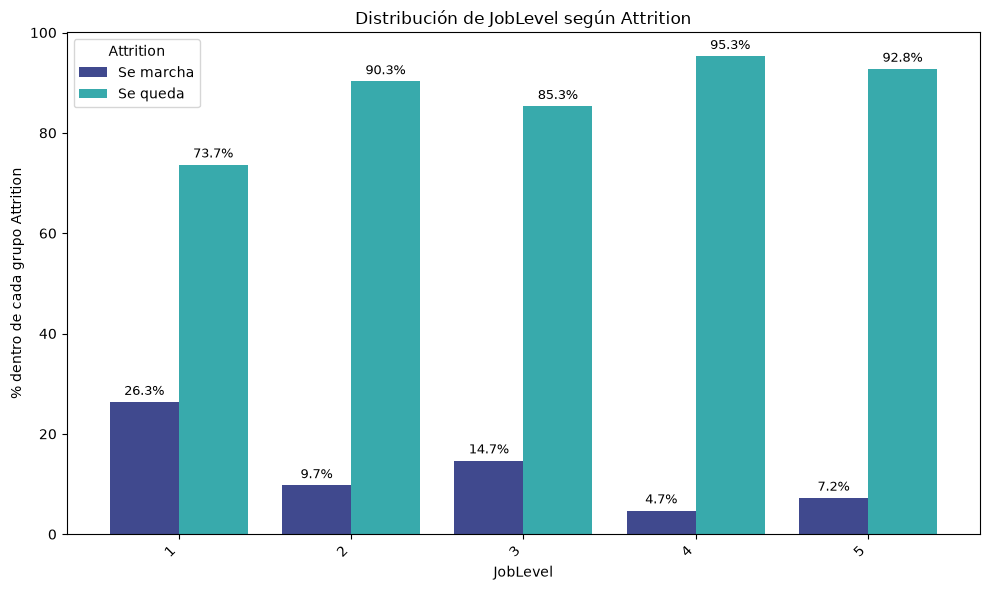

In [32]:
grafico_barras_attrition('JobLevel', bins=0, orden=None)

Teniendo en cuenta que `MonthlyIncome` y `JobLevel` presentan una correlación positiva muy fuerte en el Heatmap realizado anteriormente, los gráficos de `JobLevel` y `MonthlyIncome` analizados conjuntamente, lo que indican es que los puestos más bajos son los que tienen salarios más bajos. Por este motivo, tiene sentido que entre los empleados de nivel 1, el 26.3% abandonen la empresa, porque a su vez, son los que tienen salarios más bajos. No obstante, pese a ser el grupo con más porcentaje de rotación, no es excesivamente elevado, ya que se queda una gran mayoría del nivel 1, el 73,7%.

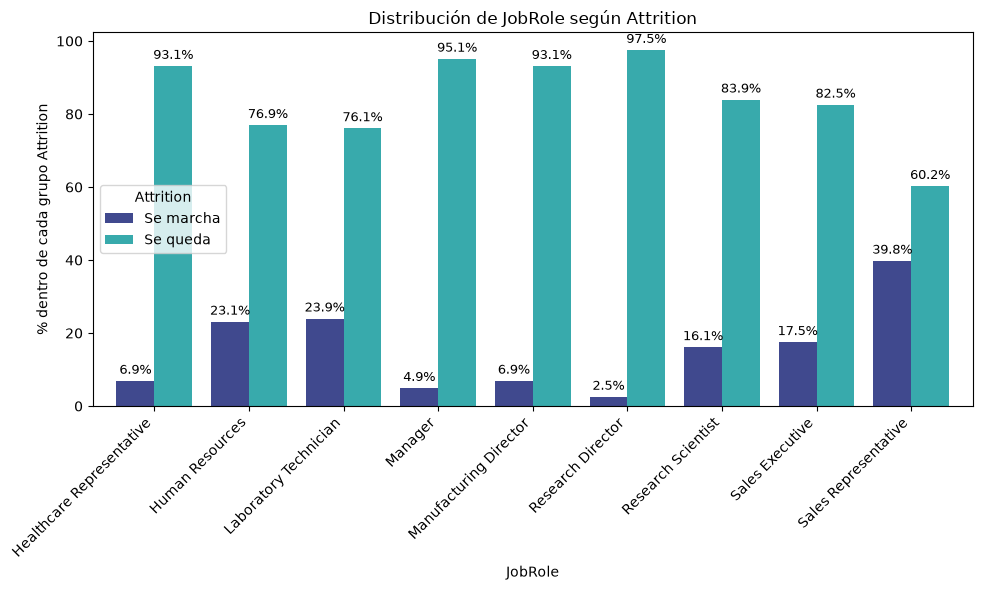

In [33]:
grafico_barras_attrition('JobRole', bins=0, orden=None)

El análisis por `JobRole` confirma que la rotación no se distribuye de forma homogénea entre todos los puestos. El porcentaje de salida es especialmente alto entre los `Sales Representative` (39,8%), seguido de `Laboratory Technician` (23,9%) y `Human Resources` (23,1%). Este patrón complementa lo observado en `MonthlyIncome` y `JobLevel`: los perfiles con menor salario o menor nivel profesional presentan mayor riesgo de salida, pero el tipo de puesto permite concretar mejor dónde se concentra ese riesgo. En cambio, roles de mayor responsabilidad o especialización, como `Manager` o `Research Director`, presentan porcentajes de rotación mucho más bajos.

In [34]:
resumen_jobrole = df_final.groupby("JobRole").agg(
    empleados=("JobRole", "count"),
    salario_medio=("MonthlyIncome", "mean"),
    salario_mediano=("MonthlyIncome", "median"),
    joblevel_medio=("JobLevel", "mean"),
    joblevel_mediano=("JobLevel", "median"),
    rotacion=("Attrition", "mean")
).reset_index()

# Pasamos rotación a porcentaje
resumen_jobrole["rotacion"] = resumen_jobrole["rotacion"] * 100

# Ordenamos de mayor a menor rotación
resumen_jobrole = resumen_jobrole.sort_values("rotacion", ascending=False)

resumen_jobrole["salario_medio"] = resumen_jobrole["salario_medio"].round(2)
resumen_jobrole["salario_mediano"] = resumen_jobrole["salario_mediano"].round(2)
resumen_jobrole["joblevel_medio"] = resumen_jobrole["joblevel_medio"].round(2)
resumen_jobrole["joblevel_mediano"] = resumen_jobrole["joblevel_mediano"].round(2)
resumen_jobrole["rotacion"] = resumen_jobrole["rotacion"].round(2)

resumen_jobrole

,JobRole,empleados,salario_medio,salario_mediano,joblevel_medio,joblevel_mediano,rotacion
8,Sales Representative,83,2673.16,2579.0,1.08,1.0,39.76
2,Laboratory Technician,259,3233.68,2886.0,1.24,1.0,23.94
1,Human Resources,52,4136.56,3093.0,1.48,1.0,23.08
7,Sales Executive,326,6912.37,6222.0,2.33,2.0,17.48
6,Research Scientist,292,3255.41,2893.0,1.20,1.0,16.10
4,Manufacturing Director,145,7294.48,6447.0,2.45,2.0,6.90
0,Healthcare Representative,131,7437.98,6781.0,2.47,2.0,6.87
3,Manager,102,17034.43,17435.0,4.30,4.0,4.90
5,Research Director,80,16033.55,16510.0,3.98,4.0,2.50


Al cruzar `JobRole` con `MonthlyIncome`, `JobLevel` y rotación, se observa que los puestos con mayor porcentaje de salida coinciden, en general, con perfiles de menor nivel profesional y menor salario. El caso más evidente es `Sales Representative`, que presenta la mayor rotación, con un 39,76%, y al mismo tiempo el salario mediano más bajo de todos los roles analizados, 2.579, junto con un `JobLevel` mediano de 1. También destacan `Laboratory Technician` y `Human Resources`, ambos con niveles medianos de 1 y tasas de rotación superiores al 23%.

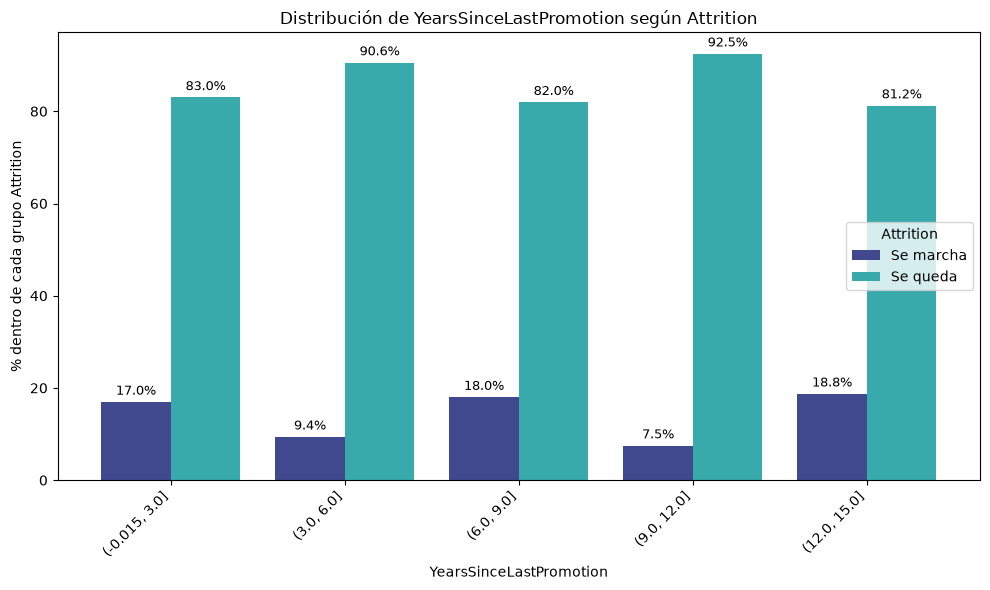

In [35]:
grafico_barras_attrition('YearsSinceLastPromotion', bins=5, orden=None)

En el caso de `YearsSinceLastPromotion`, la relación con la rotación no es lineal ni especialmente clara. Aunque algunos tramos con más años desde el último ascenso presentan porcentajes de salida elevados, también hay intervalos intermedios con porcentajes más bajos. Por tanto, esta variable no permite afirmar por sí sola que la falta de promoción sea un factor determinante de la rotación, aunque sí podría estar influyendo en determinados perfiles.

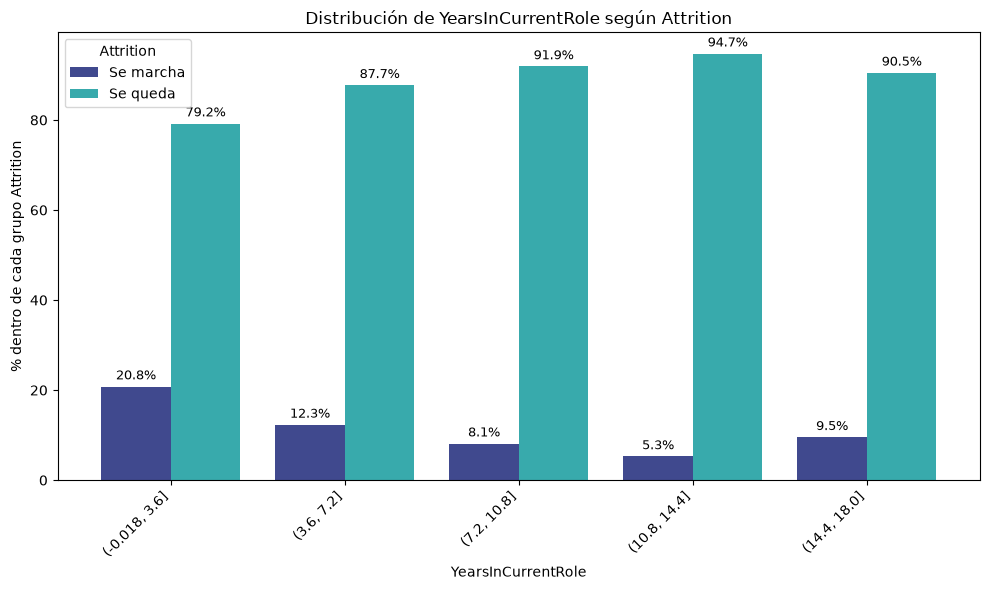

In [36]:
grafico_barras_attrition('YearsInCurrentRole', bins=5, orden=None)

Al analizar el porcentaje de salida dentro de cada tramo de `YearsInCurrentRole`, se observa que la rotación es más elevada entre quienes llevan menos tiempo en su puesto actual. En el primer intervalo, el 20,8% de los empleados abandona la empresa, mientras que en los tramos posteriores el porcentaje desciende de forma general. Esto sugiere que la salida parece estar más vinculada a fases iniciales de adaptación al rol que a una permanencia prolongada en el mismo puesto.

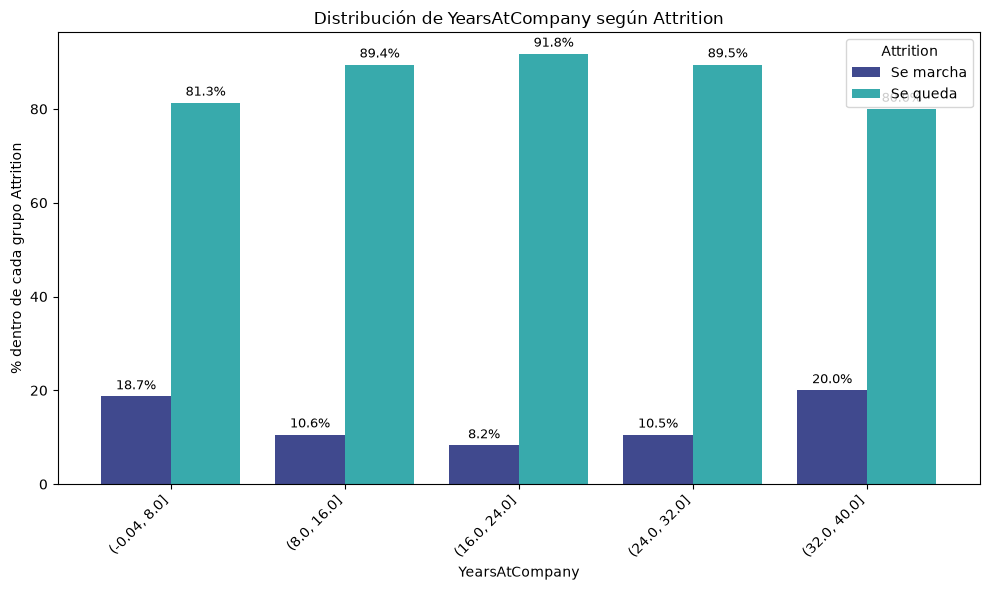

In [37]:
grafico_barras_attrition('YearsAtCompany', bins=5, orden=None)

En `YearsAtCompany`, el porcentaje de salida es más alto entre los empleados con menor antigüedad, especialmente en el tramo de 0 a 8 años. Los tramos intermedios presentan porcentajes de rotación más bajos, lo que sugiere una mayor estabilidad entre empleados con recorrido consolidado en la empresa. Aunque el tramo de mayor antigüedad también muestra un porcentaje elevado de salida, este resultado debe interpretarse con cautela, ya que probablemente corresponde a un número reducido de empleados, que al estar en el intervalo de 32 a 40 años en la empresa, es posible que algunas de salidas se deban a la jubilación.

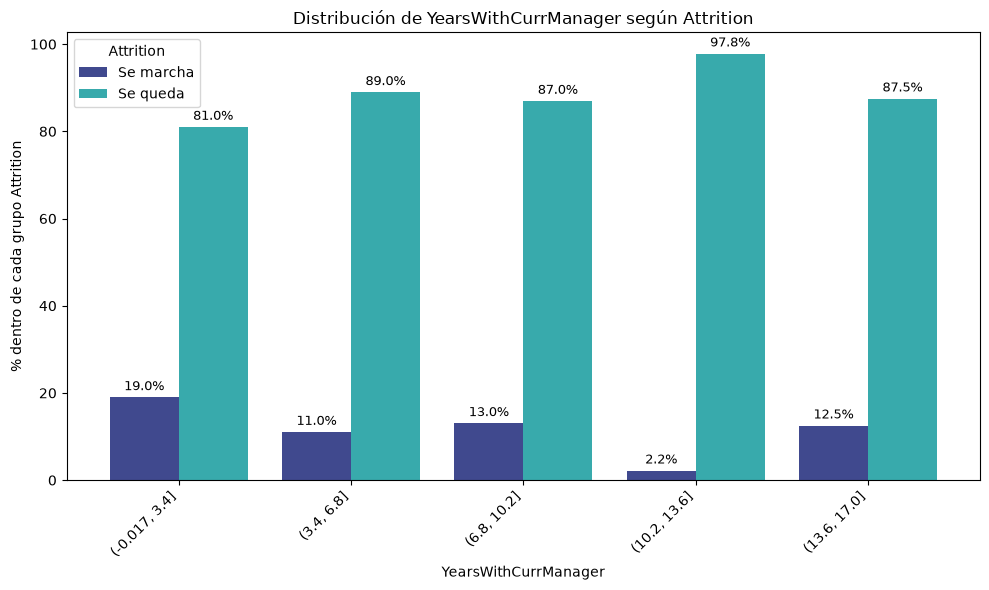

In [38]:
grafico_barras_attrition('YearsWithCurrManager', bins=5, orden=None)

Este gráfico viene a confirmar la lectura anterior, quienes llevan menos años son quienes presentan porcentajes más altos de abandono. En cualquier caso, para analizar la influencia del manager, habría que identificar a los manager y hacer un análisis individualizado de cada equipo, para observar si alguno presenta una rotación más alta que las demás.

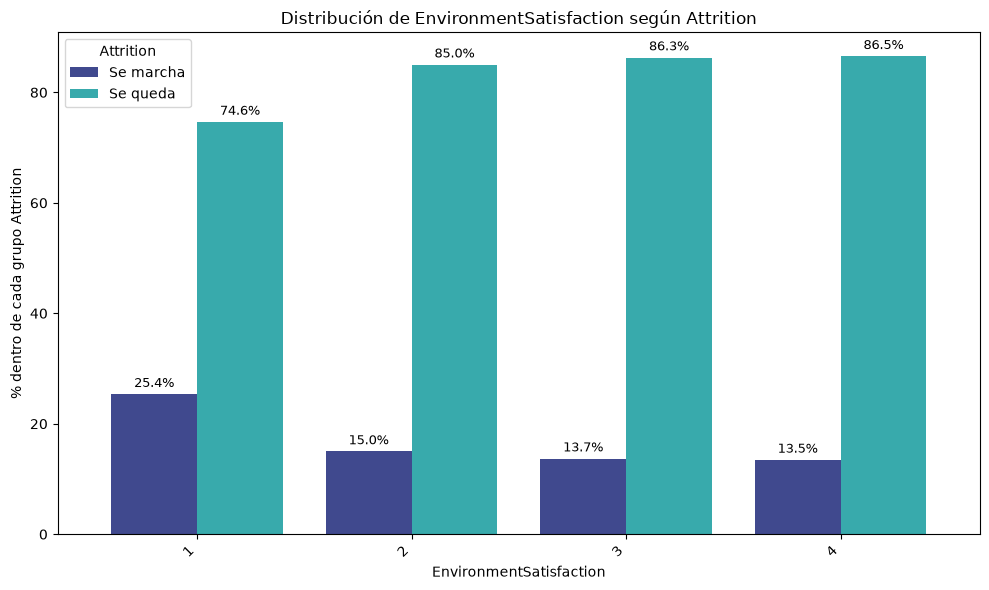

In [39]:
grafico_barras_attrition('EnvironmentSatisfaction', bins=0, orden=None)

La satisfacción con el entorno laboral parece estar relacionada con la rotación especialmente cuando la valoración es muy baja. Entre quienes puntúan ```EnvironmentSatisfaction``` con 1, el porcentaje de salida alcanza el 25,4%, mientras que en el resto de puntuaciones se sitúa alrededor del 13%-15%. Por tanto, una mala percepción del entorno puede actuar como factor de riesgo, aunque las puntuaciones medias y altas presentan comportamientos bastante similares.

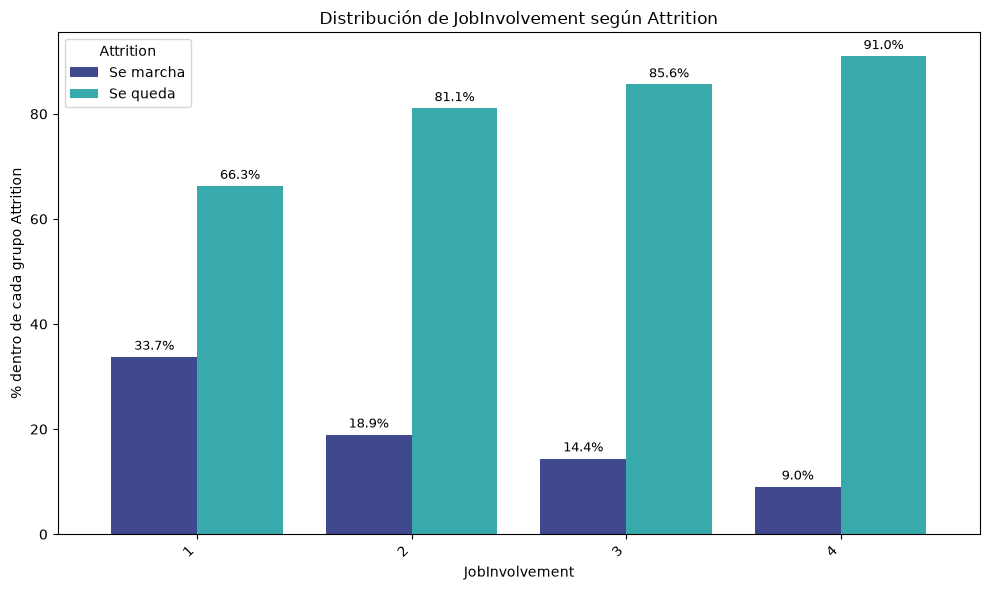

In [40]:
grafico_barras_attrition('JobInvolvement', bins=0, orden=None)

```JobInvolvement``` muestra una de las relaciones más claras con la rotación. El porcentaje de salida es muy superior entre los empleados con menor implicación laboral: el 33,7% de quienes puntúan esta variable con 1 abandona la empresa. A medida que aumenta la puntuación, el porcentaje de rotación desciende progresivamente hasta el 9% entre quienes tienen la puntuación más alta. Esto sugiere que una baja implicación con el trabajo está fuertemente asociada a un mayor riesgo de salida.

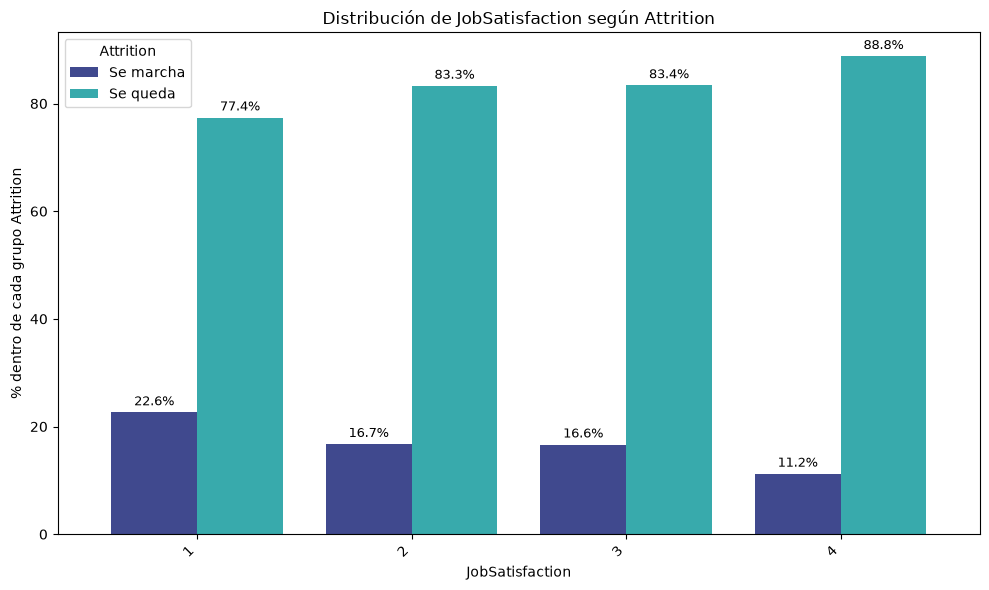

In [41]:
grafico_barras_attrition('JobSatisfaction', bins=0, orden=None)

La satisfacción laboral también parece asociarse con la rotación. El porcentaje de salida es mayor entre quienes presentan la puntuación más baja, con un 22,6%, y se reduce hasta el 11,2% entre quienes tienen la valoración más alta. No obstante, las puntuaciones intermedias muestran porcentajes muy similares, por lo que la relación no es completamente lineal. La diferencia más clara se observa entre los empleados con satisfacción muy baja y aquellos con satisfacción alta.

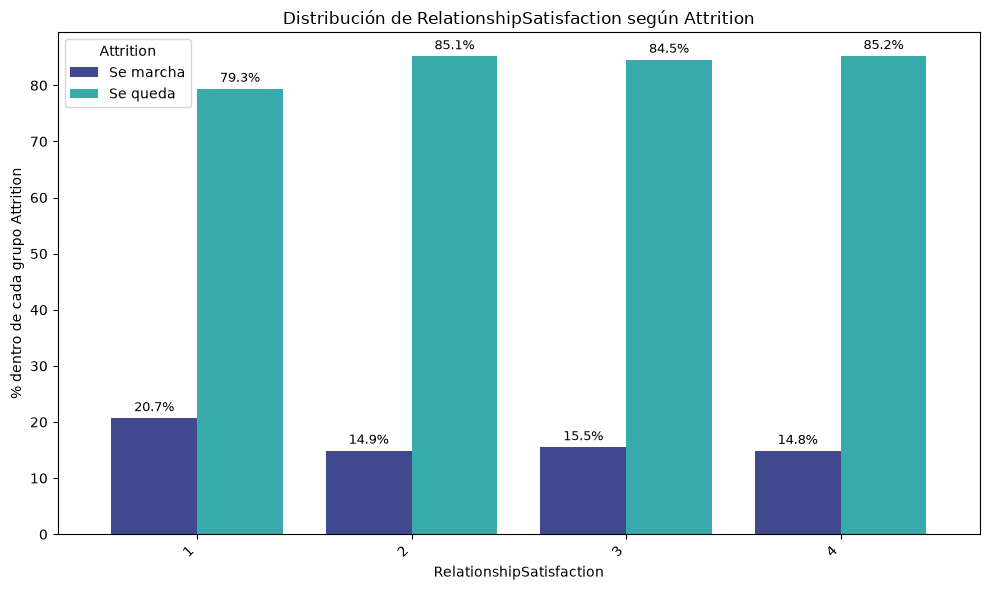

In [42]:
grafico_barras_attrition('RelationshipSatisfaction', bins=0, orden=None)

La satisfacción con las relaciones laborales muestra una asociación moderada con la rotación. Los empleados que puntúan esta variable con 1 presentan un porcentaje de salida más elevado, del 20,7%. Sin embargo, a partir de la puntuación 2, los porcentajes son muy similares entre sí. Por tanto, esta variable parece influir sobre todo cuando la valoración es muy negativa, pero no muestra una relación tan clara como otras dimensiones de la encuesta.

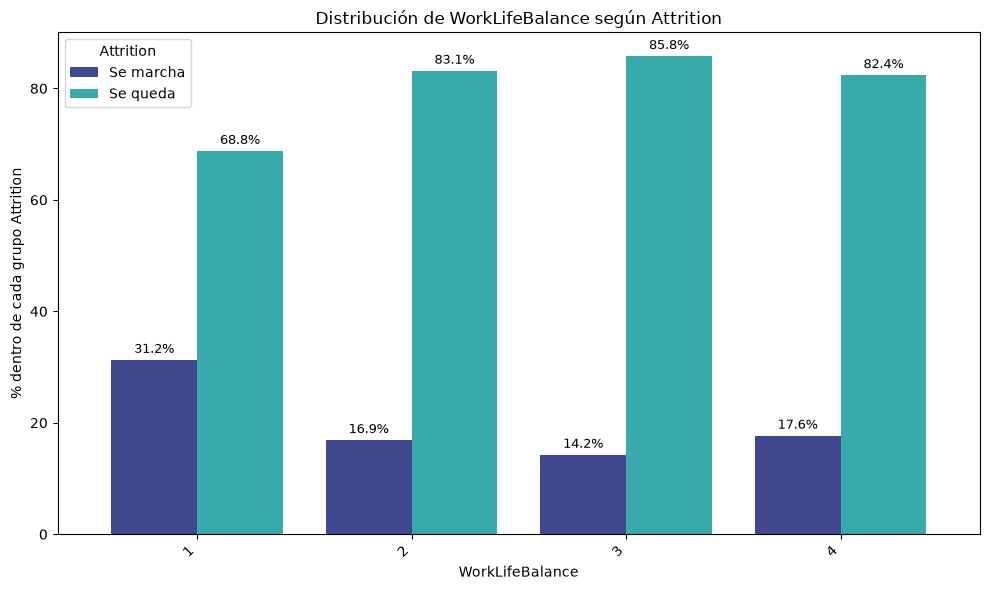

In [43]:
grafico_barras_attrition('WorkLifeBalance', bins=0, orden=None)

```WorkLifeBalance``` muestra una asociación relevante con la rotación, especialmente en la puntuación más baja. Entre quienes valoran el equilibrio vida-trabajo con 1, el porcentaje de salida asciende al 31,2%, muy por encima del resto de categorías. No obstante, la relación no es completamente lineal, ya que la puntuación 4 presenta algo más de rotación que la puntuación 3. Por tanto, una mala conciliación parece ser un factor de riesgo importante, aunque las puntuaciones medias y altas requieren una interpretación más matizada.

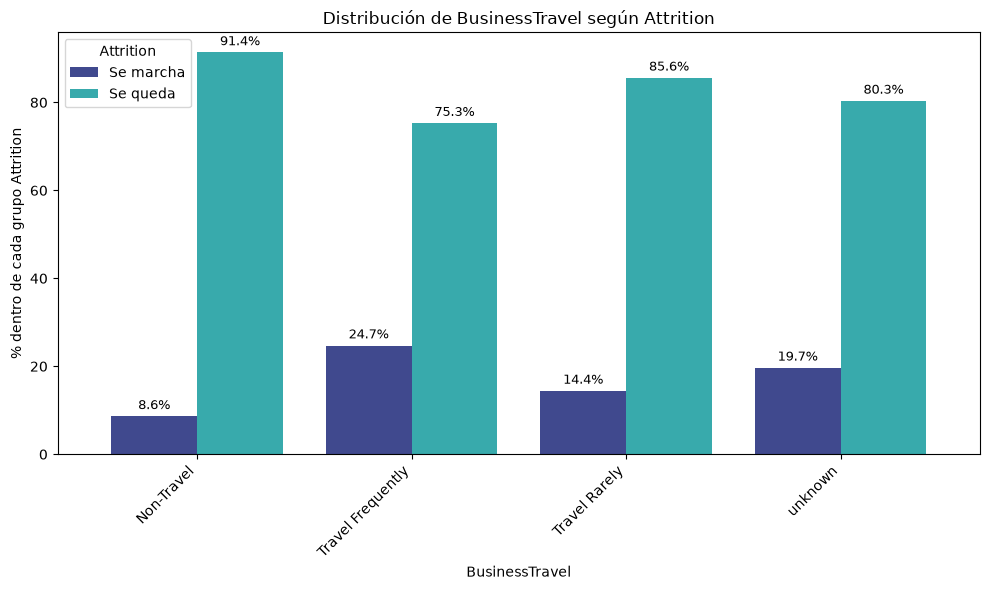

In [44]:
grafico_barras_attrition('BusinessTravel', bins=0, orden=None)

La variable ```BusinessTravel``` muestra una relación clara con la rotación. Los empleados que no viajan por trabajo presentan el menor porcentaje de salida, con un 8,6%, mientras que quienes viajan frecuentemente alcanzan el 24,7%. Esto sugiere que los desplazamientos frecuentes pueden estar asociados a un mayor riesgo de abandono, posiblemente por su impacto en la carga laboral, la conciliación o el desgaste. La categoría Travel Rarely se sitúa en un punto intermedio, con un 14,4% de salida. Por su parte, la categoría unknown debe interpretarse con cautela, al no aportar una información clara sobre el patrón real de viajes.

In [ ]:
# ¿Los empleados que viajan con más frecuencia puntúan peor en conciliación, implicación y satisfacción laboral?

# Media y mediana por tipo de viaje

variables_encuesta = ["WorkLifeBalance", "JobInvolvement", "JobSatisfaction"]

resumen_travel_encuestas = df_final.groupby("BusinessTravel")[variables_encuesta].agg(
    ["mean", "median"]
).round(2)

resumen_travel_encuestas

WorkLifeBalance        JobInvolvement         \
                             mean median           mean median   
BusinessTravel                                                   
Non-Travel                   2.75    3.0           2.63    3.0   
Travel Frequently            2.78    3.0           2.73    3.0   
Travel Rarely                2.75    3.0           2.75    3.0   
unknown                      2.83    3.0           2.68    3.0   

                  JobSatisfaction         
                             mean median  
BusinessTravel                            
Non-Travel                   2.79    3.0  
Travel Frequently            2.79    3.0  
Travel Rarely                2.72    3.0  
unknown                      2.71    3.0

In [ ]:
# Dentro de cada tipo de viaje, ¿qué porcentaje de empleados puntúa bajo en WorkLifeBalance, JobInvolvement o JobSatisfaction?

variables_encuesta = ["WorkLifeBalance", "JobInvolvement", "JobSatisfaction"]

resumen_bajas_travel = []

for variable in variables_encuesta:
    tabla = (
        df_final.groupby("BusinessTravel")[variable]
        .apply(lambda x: x.isin([1, 2]).mean() * 100)
        .reset_index(name="% puntuación baja")
    )
    
    tabla["variable"] = variable
    resumen_bajas_travel.append(tabla)

resumen_bajas_travel = pd.concat(resumen_bajas_travel, ignore_index=True)

resumen_bajas_travel.round(1)

,BusinessTravel,% puntuación baja,variable
0,Non-Travel,32.4,WorkLifeBalance
1,Travel Frequently,28.5,WorkLifeBalance
2,Travel Rarely,29.1,WorkLifeBalance
3,unknown,23.1,WorkLifeBalance
4,Non-Travel,36.0,JobInvolvement
5,Travel Frequently,30.8,JobInvolvement
6,Travel Rarely,30.5,JobInvolvement
7,unknown,31.6,JobInvolvement
8,Non-Travel,34.5,JobSatisfaction
9,Travel Frequently,35.4,JobSatisfaction


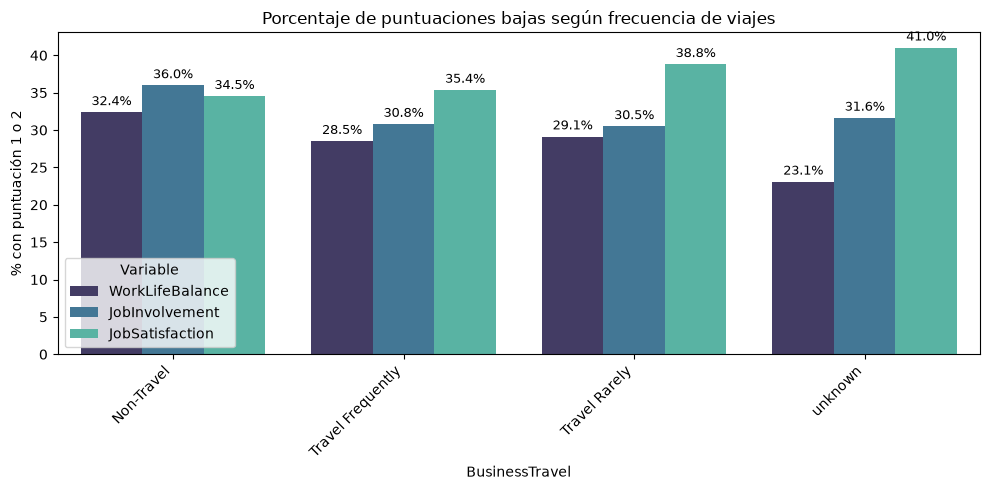

In [ ]:
# Gráfico de barras de BusinessTravel contra algunas encuestas de satisfacción

plt.figure(figsize=(10, 5))

sns.barplot(
    data=resumen_bajas_travel,
    x="BusinessTravel",
    y="% puntuación baja",
    hue="variable",
    palette="mako"
)

plt.title("Porcentaje de puntuaciones bajas según frecuencia de viajes")
plt.xlabel("BusinessTravel")
plt.ylabel("% con puntuación 1 o 2")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Variable")

for container in plt.gca().containers:
    plt.bar_label(container, fmt="%.1f%%", fontsize=9, padding=3)

plt.tight_layout()
plt.show()

Al cruzar `BusinessTravel` con las variables de encuesta, no se observa una relación clara entre una mayor frecuencia de viajes y peores valoraciones en conciliación, implicación o satisfacción laboral. Los empleados que viajan frecuentemente no presentan porcentajes de puntuaciones bajas superiores al resto de grupos; de hecho, en `WorkLifeBalance` y `JobInvolvement` sus valores son similares o incluso inferiores a los de otros perfiles. Por tanto, aunque viajar frecuentemente sí se asocia con un mayor porcentaje de rotación, esta relación no parece explicarse directamente por peores puntuaciones en estas dimensiones de la encuesta.

In [48]:
#Dentro de cada JobRole, ¿qué porcentaje de empleados viaja frecuentemente, viaja raramente, no viaja o aparece como unknown?
pd.crosstab(
    df_final["JobRole"],
    df_final["BusinessTravel"],
    normalize="index"
).mul(100).round(1)

BusinessTravel,Non-Travel,Travel Frequently,Travel Rarely,unknown
JobRole,,,,
Healthcare Representative,9.9,17.6,60.3,12.2
Human Resources,7.7,17.3,67.3,7.7
Laboratory Technician,10.4,18.1,65.6,5.8
Manager,10.8,12.7,71.6,4.9
Manufacturing Director,6.9,18.6,63.4,11.0
Research Director,7.5,15.0,75.0,2.5
Research Scientist,9.2,17.8,65.4,7.5
Sales Executive,11.3,17.5,61.3,9.8
Sales Representative,4.8,27.7,61.4,6.0


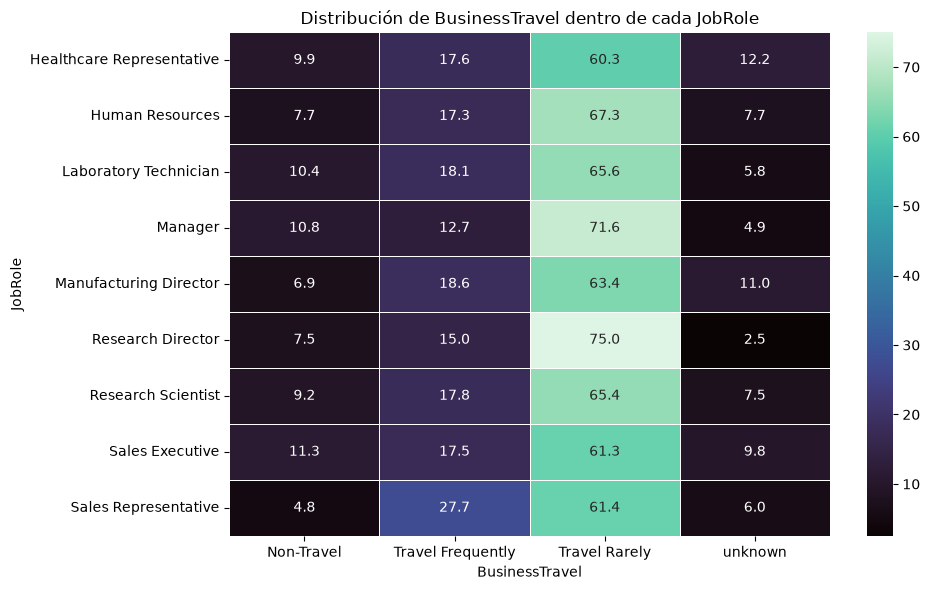

In [49]:
tabla_role_travel = pd.crosstab(
    df_final["JobRole"],
    df_final["BusinessTravel"],
    normalize="index"
).mul(100).round(1)

tabla_role_travel = tabla_role_travel[["Non-Travel", "Travel Frequently", "Travel Rarely", "unknown"]]

plt.figure(figsize=(10, 6))

sns.heatmap(
    tabla_role_travel,
    annot=True,
    fmt=".1f",
    cmap="mako",
    linewidths=0.5
)

plt.title("Distribución de BusinessTravel dentro de cada JobRole")
plt.xlabel("BusinessTravel")
plt.ylabel("JobRole")
plt.tight_layout()
plt.show()

Al analizar la frecuencia de viajes dentro de cada puesto, se observa que la mayoría de roles se concentran en la categoría `Travel Rarely`, por lo que los viajes ocasionales son el patrón más habitual. Sin embargo, ```Sales Representative``` destaca como el puesto con mayor proporción de empleados que viajan frecuentemente, con un 27,7%. Este resultado es relevante porque este mismo rol presentaba la mayor tasa de rotación, el menor salario mediano y un JobLevel mediano de 1. Por tanto, en este perfil podrían estar confluyendo varios factores de riesgo: menor nivel profesional, menor retribución, mayor exposición a viajes frecuentes y mayor probabilidad de salida.

In [50]:
#¿Los empleados que viajan frecuentemente tienen salarios más bajos, más altos o similares?
resumen_travel_income = df_final.groupby("BusinessTravel")["MonthlyIncome"].agg(
    empleados="count",
    salario_medio="mean",
    salario_mediano="median",
    salario_minimo="min",
    salario_maximo="max"
).round(2)

resumen_travel_income

,empleados,salario_medio,salario_mediano,salario_minimo,salario_maximo
BusinessTravel,,,,,
Non-Travel,139,6221.56,4876.0,1051.0,19973.0
Travel Frequently,263,6218.58,4741.0,1091.0,19847.0
Travel Rarely,951,6624.76,4907.0,1009.0,19999.0
unknown,117,6242.34,5249.0,1223.0,19717.0


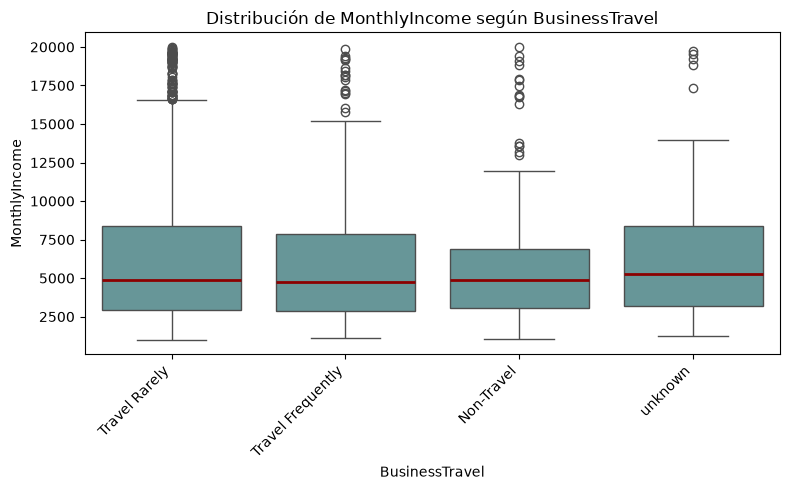

In [51]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_final,
    x="BusinessTravel",
    y="MonthlyIncome",
    color="cadetblue",
    medianprops=dict(color="darkred", linewidth=2)
)

plt.title("Distribución de MonthlyIncome según BusinessTravel")
plt.xlabel("BusinessTravel")
plt.ylabel("MonthlyIncome")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

Al cruzar ```BusinessTravel``` con ```MonthlyIncome```, no se observa una diferencia salarial especialmente marcada entre los distintos grupos de viaje. Las medianas salariales son relativamente similares y las distribuciones se solapan bastante. Por tanto, la mayor rotación observada entre quienes viajan frecuentemente no parece explicarse directamente por un menor salario mensual.

Total en el subgrupo: 76
  Se van: 32
  Se quedan: 44


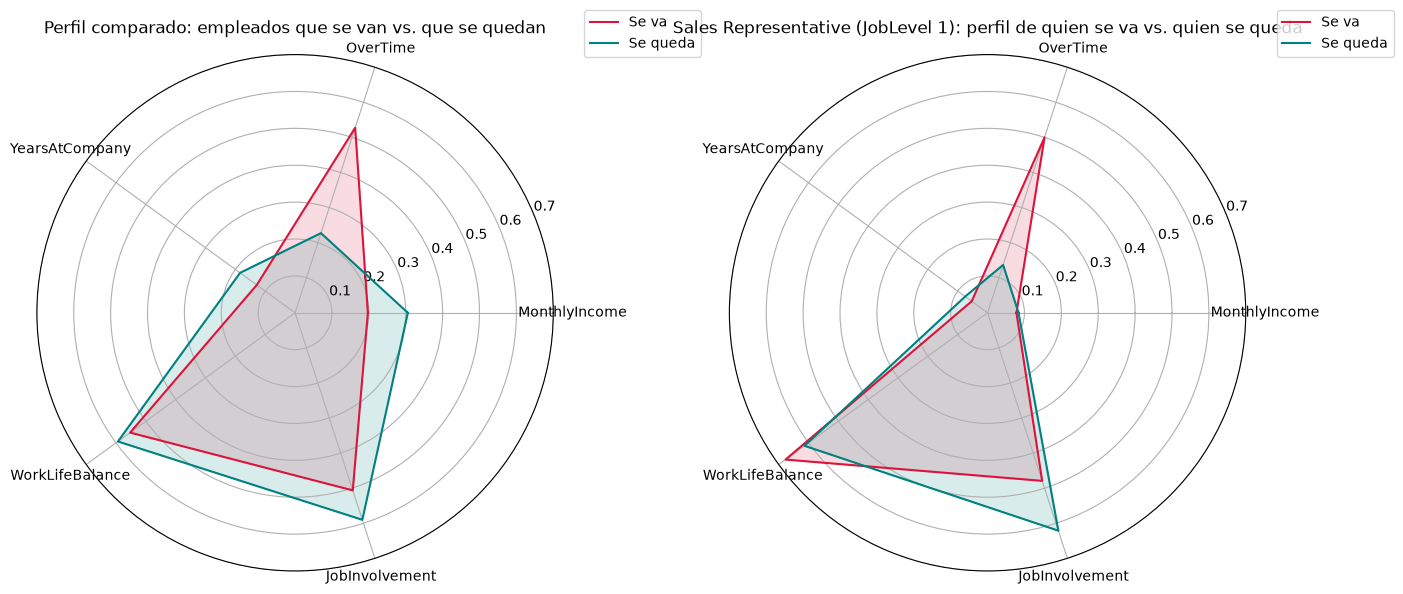

In [75]:
variables = ['MonthlyIncome', 'OverTime', 'YearsAtCompany', 'WorkLifeBalance', 'JobInvolvement']

# Normalizamos cada variable a escala 0-1 para poder compararlas en el mismo radar
df_norm = df_final.copy()

for var in variables:
    if df_final[var].dtype == 'bool' or str(df_final[var].dtype) == 'boolean':
        df_norm[var] = df_final[var].astype(int)
    else:
        df_norm[var] = (df_final[var] - df_final[var].min()) / (df_final[var].max() - df_final[var].min())

# --- Datos gráfica 1: perfil general ---
perfil_se_va_general = df_norm[df_norm['Attrition'] == True][variables].mean()
perfil_se_queda_general = df_norm[df_norm['Attrition'] == False][variables].mean()

# --- Datos gráfica 2: subgrupo Sales Representative + JobLevel 1 ---
mascara_subgrupo = (df_final['JobRole'] == 'Sales Representative') & (df_final['JobLevel'] == 1)
df_subgrupo = df_norm[mascara_subgrupo]

print(f"Total en el subgrupo: {mascara_subgrupo.sum()}")
print(f"  Se van: {(df_subgrupo['Attrition'] == True).sum()}")
print(f"  Se quedan: {(df_subgrupo['Attrition'] == False).sum()}")

perfil_se_va_subgrupo = df_subgrupo[df_subgrupo['Attrition'] == True][variables].mean()
perfil_se_queda_subgrupo = df_subgrupo[df_subgrupo['Attrition'] == False][variables].mean()

angulos = [n / len(variables) * 2 * pi for n in range(len(variables))]
angulos += angulos[:1]

# --- Figura con las dos gráficas lado a lado ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), subplot_kw=dict(polar=True))

# Gráfica 1: perfil general
for perfil, nombre, color in [(perfil_se_va_general, 'Se va', 'crimson'), (perfil_se_queda_general, 'Se queda', 'teal')]:
    valores = perfil.tolist()
    valores += valores[:1]
    ax1.plot(angulos, valores, label=nombre, color=color)
    ax1.fill(angulos, valores, alpha=0.15, color=color)

ax1.set_xticks(angulos[:-1])
ax1.set_xticklabels(variables)
ax1.set_ylim(0, 0.7)
ax1.set_title('Perfil comparado: empleados que se van vs. que se quedan')
ax1.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))

# Gráfica 2: subgrupo Sales Representative + JobLevel 1
for perfil, nombre, color in [(perfil_se_va_subgrupo, 'Se va', 'crimson'), (perfil_se_queda_subgrupo, 'Se queda', 'teal')]:
    valores = perfil.tolist()
    valores += valores[:1]
    ax2.plot(angulos, valores, label=nombre, color=color)
    ax2.fill(angulos, valores, alpha=0.15, color=color)

ax2.set_xticks(angulos[:-1])
ax2.set_xticklabels(variables)
ax2.set_ylim(0, 0.7)
ax2.set_title('Sales Representative (JobLevel 1): perfil de quien se va vs. quien se queda')
ax2.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))

plt.tight_layout()
plt.show()

Con este gráfico se puede visualizar el impacto que `OverTime` en la rotación de trabajadores que se van. Mientras que a nivel de empresa aquellos que tienen sueldos más bajos y menos años en la compañía también influye en la salida de la empresa, al centrar este dato en el grupo `Sales Representative` y en concreto en la categoría de `JobLevel` 1, se observa que la diferencia de salario y años en la compañía deja de ser clave, ganando mayor peso otras variables como `WorkLifeBalance`.